# COSC2753 Assignment 2 — Task 3: Gender & Usage Classification
- s4232487 - Do Tien Thinh

Predict two targets from fashion item images:
- **gender** — who the item is intended for (Men, Women, Boys, Girls, Unisex)
- **usage** — what occasion it is suitable for (Casual, Formal, Sports, etc.)

## Label strategy
Per the assignment spec, gender and usage may be treated as two separate targets **or** one
combined class ("It is your choice"). This notebook picks **separate classifiers** and justifies
that choice quantitatively in Section 4 (class-sparsity + Cramér's V), then confirms it
empirically in Section 12 by also training a combined-label model (Approach B) and a dual-head
model (Approach C) purely as **comparison / justification baselines** — neither is a candidate
for the final submitted model.

## Model lineup (final, trimmed)
| # | Model | Role |
|---|-------|------|
| 1 | Logistic Regression (metadata only) | Baseline — sets the floor |
| 2 | Image-only comparison — SmallCNN / ImprovedSmallCNN / SEResidualCNN / ResNet18-from-scratch (best kept) | From-scratch, no metadata — isolates how much signal the image alone carries |
| 3 | MultiInput — Pretrained ResNet18 (image+metadata, concatenation) | Comparison only — **not** eligible for submission (pretrained) |
| 4 | MultiInput — ImprovedSmallCNN (image+metadata, **concatenation** fusion) | From-scratch, main image+metadata model |
| 5 | MultiInput — **Gated Fusion** (image+metadata) | From-scratch, second fusion strategy — shows exploration beyond plain concatenation |
| 6 | **Soft-voting ensemble** (LogReg ⊕ SmallCNN, unweighted 50/50) | From-scratch, no extra training — decision-level fusion of models 1 & 4 |

Approach B (combined label) and Approach C (dual-head) are trained and evaluated too, but only to
**justify** the separate-classifier decision with real numbers — they are excluded from
best-model selection in Section 12.

**Reused from Task 2:** split logic, dataset classes, model architectures (SmallCNN, ResNet18, MultiInputNet),
`fit()` / `run_epoch()` / `evaluate()` training utilities, metadata pipeline, EarlyStopping.

**New in Task 3:** Cramér's V independence check, image-only model comparison (SmallCNN /
ImprovedSmallCNN / SEResidualCNN / ResNet18-from-scratch vs. pretrained ResNet18 / MobileNetV3),
gated-fusion architecture, soft-voting ensemble, combined-label approach, dual-head model,
separate gender/usage evaluation.

## 0. Configuration — switch between TEST and REAL mode here

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  MODE SWITCH — set to True for a quick sanity-check run, False for full training
# ─────────────────────────────────────────────────────────────────────────────
TESTING_MODE = False  # <── change this only

if TESTING_MODE:
    # Fast smoke-test: small subset, large batches, few epochs
    SUBSET_SIZE   = 2000    # number of rows sampled from the full train CSV
    BATCH_SIZE    = 128     # larger batch = fewer optimizer steps per epoch
    EPOCHS        = 5       # just enough to confirm the forward pass works
    PATIENCE      = 3       # early-stopping patience
    NUM_WORKERS   = 0       # 0 avoids multiprocessing overhead on small runs
    IMG_SIZE      = (60, 80)  # smaller images → faster data loading
    LR            = 3e-4
    print("[TESTING MODE] Small subset, fast settings.")
else:
    # Full training run — use all data with production-quality settings
    SUBSET_SIZE   = None    # None = use entire dataset
    BATCH_SIZE    = 64
    EPOCHS        = 50
    PATIENCE      = 10
    NUM_WORKERS   = 4
    IMG_SIZE      = (80, 60)  # native image ratio
    LR            = 3e-4
    print("[REAL MODE] Full dataset, full training.")

[REAL MODE] Full dataset, full training.


## 1. Imports

In [2]:
import os
import copy
import pickle
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)
import joblib

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights
)
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 2. Paths

In [ ]:
DATA_DIR         = Path("../data/raw/FashionDataset")
TRAIN_CSV        = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV    = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR  = DATA_DIR / "test" / "images_test"
PROCESSED_DIR    = Path("../data/processed")
OUTPUT_DIR       = Path("../outputs/task3_models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")


REQUIRED_PROCESSED = {
    "config":     PROCESSED_DIR / "pipeline_config.json",
    "encoders":   PROCESSED_DIR / "label_encoders.pkl",
    "train_full": PROCESSED_DIR / "train_full.csv",
    "val_full":   PROCESSED_DIR / "val_full.csv",
}
for name, path in REQUIRED_PROCESSED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:10s} {path}")
_missing_processed = [k for k, v in REQUIRED_PROCESSED.items() if not v.exists()]
if _missing_processed:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {_missing_processed}")

[OK] ../data/raw/FashionDataset/train/styles_train.csv
[OK] ../data/raw/FashionDataset/train/images_train
[OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[OK] ../data/raw/FashionDataset/test/images_test
[     OK] config     ../data/processed/pipeline_config.json
[     OK] encoders   ../data/processed/label_encoders.pkl
[     OK] train_full ../data/processed/train_full.csv
[     OK] val_full   ../data/processed/val_full.csv


## 3. Load & clean dataset
*(Reused from Task 2 — same cleaning logic)*

In [ ]:

import json

with open(REQUIRED_PROCESSED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Image geometry and normalisation come from the preprocessing notebook. IMG_SIZE set in
# Section 0 is overridden here so this notebook trains on exactly the tensors the pipeline
# notebook will feed it at inference time -- a different normalisation would silently
# degrade every prediction the chain makes.
IMG_HEIGHT = config["image"]["height"]
IMG_WIDTH  = config["image"]["width"]
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
NORM_MEAN  = config["image"]["normalization_mean"]
NORM_STD   = config["image"]["normalization_std"]

ID_DTYPE = {"id": str}
train_full = pd.read_csv(REQUIRED_PROCESSED["train_full"], dtype=ID_DTYPE)
val_full   = pd.read_csv(REQUIRED_PROCESSED["val_full"],   dtype=ID_DTYPE)
with open(REQUIRED_PROCESSED["encoders"], "rb") as f:
    shared_encoders = pickle.load(f)

TRAIN_IDS = set(train_full["id"])
VAL_IDS   = set(val_full["id"])
assert not (TRAIN_IDS & VAL_IDS), "saved split overlaps -- re-run preprocessing"

df = pd.concat([train_full, val_full], ignore_index=True)
df["id"] = df["id"].astype(str).str.strip()

print(f"Loaded saved split: train {len(train_full)}, val {len(val_full)}, combined {len(df)}")
print(f"Seed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in NORM_MEAN]}, std {[round(v, 4) for v in NORM_STD]}")

# Optional subset for TESTING_MODE (unchanged behaviour -- both halves shrink together,
# since Section 6 re-derives train/val from whatever rows survive here).
if TESTING_MODE and SUBSET_SIZE:
    df = df.sample(min(SUBSET_SIZE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[TESTING MODE] Subsampled to {len(df)} rows")

Loaded saved split: train 28371, val 9457, combined 37828
Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]


In [ ]:

assert 'dup_group' in df.columns, \
    "dup_group missing -- re-run COSC2753_A2_Preprocessing.ipynb to regenerate train_full/val_full"
print(f"{df['dup_group'].nunique()} unique image groups in {len(df)} rows")

37828 unique image groups in 37828 rows


## 4. Target label exploration

In [6]:
print("=== gender ===")
print(df['gender'].value_counts())
print("\n=== usage ===")
print(df['usage'].value_counts())

=== gender ===
gender
Men       20576
Women     14108
Unisex     2075
Boys        586
Girls       483
Name: count, dtype: int64

=== usage ===
usage
Casual          28964
Sports           3933
Ethnic           2564
Formal           2203
Smart Casual       55
Travel             25
Party              13
Name: count, dtype: int64


In [7]:
# Drop rows with missing target labels — these can't be trained on
before = len(df)
df = df.dropna(subset=['gender', 'usage']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing gender or usage labels")

# Combined label for the joint-classifier approach
df['gender_usage'] = df['gender'] + '__' + df['usage']
print(f"\nUnique gender x usage combinations: {df['gender_usage'].nunique()}")
print(df['gender_usage'].value_counts().head(15))

Dropped 71 rows with missing gender or usage labels

Unique gender x usage combinations: 23
gender_usage
Men__Casual          15451
Women__Casual        10729
Men__Sports           2871
Women__Ethnic         2456
Men__Formal           2097
Unisex__Casual        1754
Women__Sports          759
Boys__Casual           556
Girls__Casual          474
Unisex__Sports         282
Women__Formal          105
Men__Ethnic             90
Men__Smart Casual       44
Unisex__Travel          20
Boys__Sports            20
Name: count, dtype: int64


Dropping 7 rows with rare gender_usage combinations


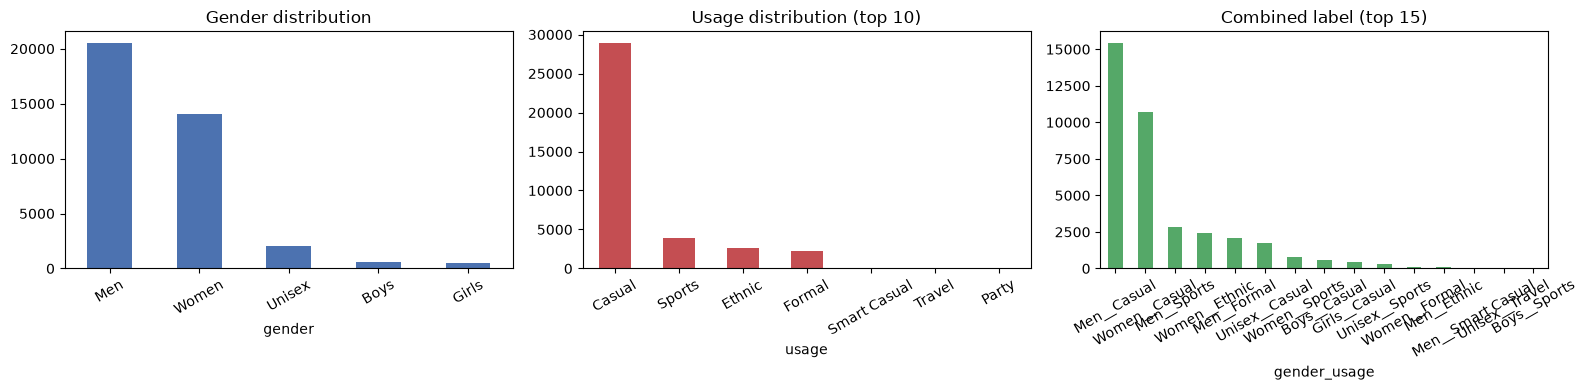

In [8]:
# Drop rare combined classes (< 5 samples) — can't split or train on them reliably
combo_counts = df['gender_usage'].value_counts()
rare_combos  = combo_counts[combo_counts < 5].index
if len(rare_combos):
    print(f"Dropping {df['gender_usage'].isin(rare_combos).sum()} rows with rare gender_usage combinations")
    df = df[~df['gender_usage'].isin(rare_combos)].reset_index(drop=True)

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Gender distribution'); axes[0].tick_params(axis='x', rotation=30)

df['usage'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Usage distribution (top 10)'); axes[1].tick_params(axis='x', rotation=30)

df['gender_usage'].value_counts().head(15).plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Combined label (top 15)'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4.1 Cramér's V — are gender and usage independent?

If gender and usage were strongly associated, a combined label could exploit that joint
structure. If they are only weakly associated, a combined label buys nothing while multiplying
the number of classes. We check this quantitatively before deciding which approach to commit to.

In [9]:
from scipy.stats import chi2_contingency

def cramers_v(col_a, col_b):
    """Cramer's V -- bias-corrected, symmetric measure of association between
    two categorical variables. 0 = independent, 1 = perfectly associated."""
    confusion = pd.crosstab(col_a, col_b)
    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

v_gender_usage = cramers_v(df['gender'], df['usage'])
print(f"Cramer's V (gender vs usage): {v_gender_usage:.3f}")

# Sparsity of the combined label space
combo_counts = df['gender_usage'].value_counts()
n_combos     = len(combo_counts)
n_sparse     = (combo_counts < 10).sum()
n_possible   = df['gender'].nunique() * df['usage'].nunique()

print(f"\nCombined label space: {n_combos} observed combinations out of "
      f"{n_possible} theoretically possible "
      f"({df['gender'].nunique()} genders x {df['usage'].nunique()} usages)")
print(f"{n_sparse}/{n_combos} observed combinations have fewer than 10 samples")

Cramer's V (gender vs usage): 0.205

Combined label space: 19 observed combinations out of 35 theoretically possible (5 genders x 7 usages)
1/19 observed combinations have fewer than 10 samples


### 4.2 Decision: treat gender and usage as two separate targets

Based on the analysis above, this notebook uses **two separate classifiers** rather than one
combined `gender__usage` class. Reasoning:

1. **Class explosion / sparsity.** The combined label space has far more classes than either
   target alone, and a large share of the observed combinations have very few samples (printed
   above). Sparse classes are hard to learn and unreliable to evaluate.
2. **Weak association.** The Cramér's V score above is well below 1 — gender and usage are
   largely independent signals, so modelling their joint distribution buys little while the
   class count multiplies.
3. **Independent error analysis.** Separate models give a clean confusion matrix per target, so
   we can tell whether a mistake is a *gender* mistake or a *usage* mistake — impossible with one
   joint label.
4. **Deployment realism.** In a real catalogue/search system, "filter by Women" and "filter by
   Formal" are independent filters a user can apply on their own — separate models mirror that
   use case.
5. **Empirical confirmation (Section 12).** Approach B (combined label) and Approach C (dual-head)
   are still trained and evaluated as comparison baselines. Both underperform the separate
   classifiers (Approach A) on validation Macro-F1 — the strongest evidence that the
   separate-target decision was correct for this dataset.

## 5. Label encoding

In [10]:
gender_enc       = LabelEncoder()
usage_enc        = LabelEncoder()
gender_usage_enc = LabelEncoder()

df['gender_label']       = gender_enc.fit_transform(df['gender'])
df['usage_label']        = usage_enc.fit_transform(df['usage'])
df['gender_usage_label'] = gender_usage_enc.fit_transform(df['gender_usage'])

N_GENDER       = len(gender_enc.classes_)
N_USAGE        = len(usage_enc.classes_)
N_COMBINED     = len(gender_usage_enc.classes_)

print(f"Gender classes ({N_GENDER}):        {list(gender_enc.classes_)}")
print(f"Usage classes ({N_USAGE}):          {list(usage_enc.classes_)}")
print(f"Combined classes ({N_COMBINED}):    {list(gender_usage_enc.classes_)[:8]} ...")

Gender classes (5):        ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
Usage classes (7):          ['Casual', 'Ethnic', 'Formal', 'Party', 'Smart Casual', 'Sports', 'Travel']
Combined classes (19):    ['Boys__Casual', 'Boys__Ethnic', 'Boys__Sports', 'Girls__Casual', 'Girls__Ethnic', 'Men__Casual', 'Men__Ethnic', 'Men__Formal'] ...


## 6. Train / Validation split
*(Same leak-free strategy as Tasks 1 & 2: StratifiedGroupKFold on masterCategory)*

In [ ]:

train_data = df[df['id'].isin(TRAIN_IDS)].reset_index(drop=True)
val_data   = df[df['id'].isin(VAL_IDS)].reset_index(drop=True)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate groups in both splits: {len(overlap)} (should be 0)")

assert len(train_data) + len(val_data) == len(df), "rows lost when re-deriving the split"
assert not (set(train_data['id']) & set(val_data['id'])), "id overlap between train and val"
assert len(train_data) and len(val_data), "one side of the split is empty -- check SUBSET_SIZE"

Train: 28311, Val: 9439
Duplicate groups in both splits: 0 (should be 0)


## 7. Metadata features
*(Same one-hot pipeline as Task 2 — reused directly)*

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Task 3 metadata: exclude gender and usage (they are the targets — leakage if included)
# Also exclude season (it was Task 2's target — still useful here as a feature)
META_COLS = ['masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'season']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
meta_train = ohe.fit_transform(train_data[META_COLS])
meta_val   = ohe.transform(val_data[META_COLS])
META_DIM   = meta_train.shape[1]

print(f"Metadata feature dimension: {META_DIM}")

joblib.dump(ohe, OUTPUT_DIR / 'ohe_metadata.joblib')
joblib.dump(gender_enc,       OUTPUT_DIR / 'gender_encoder.joblib')
joblib.dump(usage_enc,        OUTPUT_DIR / 'usage_encoder.joblib')
joblib.dump(gender_usage_enc, OUTPUT_DIR / 'gender_usage_encoder.joblib')
print("Encoders saved.")

Metadata feature dimension: 228
Encoders saved.


## 8. Shared utilities
*(Reused verbatim from Task 2)*

In [ ]:
# ── Image transforms ──────────────────────────────────────────────────────────
H, W = IMG_SIZE

train_transform = T.Compose([
    T.Resize((H, W)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])

eval_transform = T.Compose([
    T.Resize((H, W)),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])


# ── Weighted sampler for class imbalance ──────────────────────────────────────
def get_weighted_sampler(frame, label_col):
    counts  = frame[label_col].value_counts().to_dict()
    weights = frame[label_col].map(lambda c: 1.0 / counts[c]).values
    return WeightedRandomSampler(weights, len(weights), replacement=True)


# ── Dataset classes ───────────────────────────────────────────────────────────
class FashionImageDataset(Dataset):
    """Image-only dataset for single-label tasks."""
    def __init__(self, frame, image_dir, label_col, transform):
        self.frame     = frame.reset_index(drop=True)
        self.image_dir = image_dir
        self.label_col = label_col
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        with Image.open(self.image_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        return img, torch.tensor(row[self.label_col], dtype=torch.long)


class MultiInputDataset(Dataset):
    """Image + metadata dataset for single-label tasks."""
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame     = frame.reset_index(drop=True)
        self.metadata  = metadata
        self.labels    = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta = torch.tensor(self.metadata[i], dtype=torch.float32)
        lbl  = torch.tensor(self.labels[i],   dtype=torch.long)
        return img, meta, lbl


class DualLabelDataset(Dataset):
    """Image + metadata dataset that returns TWO labels (gender, usage).
    Used by the dual-head model."""
    def __init__(self, frame, metadata, gender_labels, usage_labels, image_dir, transform):
        self.frame         = frame.reset_index(drop=True)
        self.metadata      = metadata
        self.gender_labels = gender_labels
        self.usage_labels  = usage_labels
        self.image_dir     = image_dir
        self.transform     = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta   = torch.tensor(self.metadata[i],      dtype=torch.float32)
        g_lbl  = torch.tensor(self.gender_labels[i], dtype=torch.long)
        u_lbl  = torch.tensor(self.usage_labels[i],  dtype=torch.long)
        return img, meta, g_lbl, u_lbl

In [14]:
# ── Model building blocks (reused from Task 2) ────────────────────────────────

class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Sequential()
        )
    def forward(self, x):
        return self.act(self.bn2(self.conv2(self.act(self.bn1(self.conv1(x))))) + self.shortcut(x))


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections (from Task 2)."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = ConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = ConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = ConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.SiLU()
        )
    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


class MultiInputNet(nn.Module):
    """Image encoder + metadata MLP → single classification head."""
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_encoder.out_dim + 128, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )
    def forward(self, image, metadata):
        return self.head(torch.cat([self.image(image), self.meta(metadata)], dim=1))


class GatedFusionNet(nn.Module):
    """Image encoder + metadata MLP, fused with a *gate* instead of a plain
    concatenation. A small gate network looks at both modalities and learns,
    per-sample, how much to trust the image branch vs. the metadata branch:
        gate  = sigmoid(W [image_feat ; meta_feat])
        fused = gate * image_feat + (1 - gate) * meta_feat
    This is the second fusion strategy investigated alongside the plain
    concatenation used by MultiInputNet above -- it lets the model down-weight
    one modality per-sample instead of always trusting both equally."""
    def __init__(self, metadata_dim, n_classes, image_encoder, fusion_dim=128):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, fusion_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.image_proj = nn.Linear(image_encoder.out_dim, fusion_dim)
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim), nn.Sigmoid()
        )
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )

    def forward(self, image, metadata):
        img_feat  = self.image_proj(self.image(image))
        meta_feat = self.meta(metadata)
        g = self.gate(torch.cat([img_feat, meta_feat], dim=1))
        fused = g * img_feat + (1 - g) * meta_feat
        return self.head(fused)


# ── NEW for Task 3: Dual-head model ───────────────────────────────────────────
class DualHeadNet(nn.Module):
    """Shared image+metadata backbone with two separate classification heads:
    one for gender, one for usage. Jointly trained with a weighted sum of losses."""
    def __init__(self, metadata_dim, n_gender, n_usage, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        fused_dim = image_encoder.out_dim + 128
        self.shared = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.gender_head = nn.Linear(256, n_gender)
        self.usage_head  = nn.Linear(256, n_usage)

    def forward(self, image, metadata):
        fused  = torch.cat([self.image(image), self.meta(metadata)], dim=1)
        shared = self.shared(fused)
        return self.gender_head(shared), self.usage_head(shared)

In [15]:
# ── Training utilities (reused from Task 2) ───────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=5, delta=0, mode='min'):
        assert mode in ('max', 'min')
        self.patience = patience; self.delta = delta; self.mode = mode
        self.best_score = None; self.early_stop = False
        self.counter = 0; self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """Move all tensors in batch to DEVICE; last tensor is always the label(s)."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()
    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss   = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad(); loss.backward(); optimiser.step()
            running_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def fit(model, loader_tr, loader_va, model_name='model', patience=PATIENCE, lr=LR):
    criterion    = nn.CrossEntropyLoss()
    optimiser    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper      = EarlyStopping(patience=patience, mode='min')
    history      = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    # FIX: also track train F1 AT the best (early-stopping-selected) epoch, not
    # just val F1 — needed to plot train vs val F1 side by side later.
    best_val_f1  = None; best_train_f1 = None; best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch+1}/{EPOCHS}'
        tr_loss, tr_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        va_loss, va_f1 = run_epoch(model, loader_va, criterion, None,      desc=f'{tag} val')
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(va_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1={tr_f1:.4f}  va_f1={va_f1:.4f}  lr={current_lr:.2e}')
        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_f1 = va_f1; best_train_f1 = tr_f1; best_epoch = epoch + 1
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best epoch={best_epoch})')
            break

    model = stopper.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> {model_name}: best epoch={best_epoch}, train_f1={best_train_f1:.4f}, val_f1={best_val_f1:.4f}')
    return model, best_val_f1, best_train_f1, best_epoch


def evaluate(model, loader, label_col='single'):
    model.eval(); preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train'); axes[1].plot(history['val_f1'], label='Val')
    axes[1].set_title('Macro-F1'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


## 9. Approach A — Two separate classifiers (gender | usage)

Train one model for each target independently. Simpler, but ignores the correlation between gender and usage.

This section is split into two clearly separate parts:

- **Part 1 — Single-input models (9.1–9.2):** each model sees only *one* modality — either the
  tabular metadata (9.1) or the product image (9.2) — with nothing fused together. This
  establishes the floor for each modality in isolation, and 9.2 also picks the best from-scratch
  image architecture per label.
- **Part 2 — Multi-input models (9.3–9.8):** every model from here on sees **both** the image and
  the metadata at once, fused either by concatenation (`MultiInputNet`, 9.3–9.6), a learned gate
  (`GatedFusionNet`, 9.7), or a decision-level soft vote (9.8). These models plug in whichever
  from-scratch image encoder actually won Part 1 for that label (see 9.2.6), rather than a fixed
  architecture chosen ahead of time.

In [16]:
# ── Labels ────────────────────────────────────────────────────────────────────
y_gender_train = train_data['gender_label'].values
y_gender_val   = val_data['gender_label'].values
y_usage_train  = train_data['usage_label'].values
y_usage_val    = val_data['usage_label'].values

# ── Weighted samplers ─────────────────────────────────────────────────────────
sampler_gender = get_weighted_sampler(train_data, 'gender_label')
sampler_usage  = get_weighted_sampler(train_data, 'usage_label')

/workspace/myenv/lib/python3.12/site-packages/torch/utils/data/sampler.py:264: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


### 9.1.5 Metadata feature ablation — which columns matter most for gender / usage?

Before fitting the LogReg baseline on the full metadata vector, we run a quick
**leave-one-feature-out ablation** using a RandomForest (fast, handles categorical and numeric
together). For each target we train once on ALL metadata columns, then once per column with that
column removed. A large drop in val F1 when a column is removed means that column carries
important signal; a negligible drop means it can be pruned without hurting performance.

The ablation is run **before** the OHE / LogReg baseline so the findings can inform whether
to drop any column from `META_COLS` (commented-out candidate in the cell below the results).

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder as _OHE, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ── Feature ablation: which metadata columns actually matter for gender/usage? ──
# Same idea as Task 2's ablation, run separately per Task 3 target since gender
# and usage are independent classification problems with possibly different
# feature dependencies.
FEATURE_GROUPS_T3 = {col: [col] for col in META_COLS}   # META_COLS from Section 7
CAT_COLS_T3 = ['masterCategory', 'subCategory', 'articleType', 'baseColour', 'season']
NUM_COLS_T3 = ['year']


def run_rf_ablation_t3(name, train_matrix, val_matrix, y_tr, y_va):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_tr)
    train_f1 = f1_score(y_tr, model.predict(train_matrix), average='macro', zero_division=0)
    val_f1   = f1_score(y_va, model.predict(val_matrix),   average='macro', zero_division=0)
    print(f'{name:32s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1


def build_metadata_matrix_groups_t3(train_df, val_df, active_groups):
    """Builds a design matrix using only the given META_COLS groups."""
    cat_features = [c for c in active_groups if c in CAT_COLS_T3]
    num_features = [c for c in active_groups if c in NUM_COLS_T3]
    if not (cat_features or num_features):
        raise ValueError('At least one feature group must be selected.')

    transformers = []
    if cat_features:
        transformers.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', _OHE(handle_unknown='ignore'))
        ]), cat_features))
    if num_features:
        transformers.append(('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_features))

    preprocessor = ColumnTransformer(transformers)
    cols = cat_features + num_features
    Xtr, Xva = train_df[cols].copy(), val_df[cols].copy()
    for c in cat_features:
        Xtr[c] = Xtr[c].astype(object); Xva[c] = Xva[c].astype(object)
    for c in num_features:
        Xtr[c] = pd.to_numeric(Xtr[c], errors='coerce')
        Xva[c] = pd.to_numeric(Xva[c], errors='coerce')

    Mtr = preprocessor.fit_transform(Xtr)
    Mva = preprocessor.transform(Xva)
    Mtr = Mtr.toarray() if hasattr(Mtr, 'toarray') else Mtr
    Mva = Mva.toarray() if hasattr(Mva, 'toarray') else Mva
    return Mtr.astype('float32'), Mva.astype('float32')


all_groups_t3 = list(FEATURE_GROUPS_T3.keys())

for target_name, y_tr, y_va in [('gender', y_gender_train, y_gender_val),
                                  ('usage',  y_usage_train,  y_usage_val)]:
    print(f'\n=== Ablation for target: {target_name} ===')
    ablation_results = {}

    m_tr, m_va = build_metadata_matrix_groups_t3(train_data, val_data, active_groups=all_groups_t3)
    ablation_results['Full Model (Baseline)'] = run_rf_ablation_t3(
        'Full Model (Baseline)', m_tr, m_va, y_tr, y_va)

    for group_to_drop in all_groups_t3:
        remaining = [g for g in all_groups_t3 if g != group_to_drop]
        m_tr, m_va = build_metadata_matrix_groups_t3(train_data, val_data, active_groups=remaining)
        label = f'Without {group_to_drop}'
        ablation_results[label] = run_rf_ablation_t3(label, m_tr, m_va, y_tr, y_va)

    ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
    display(ablation_df.round(4))


=== Ablation for target: gender ===
Full Model (Baseline)            train F1: 0.4839  val F1: 0.4556
Without masterCategory           train F1: 0.4842  val F1: 0.4555
Without subCategory              train F1: 0.4836  val F1: 0.4565
Without articleType              train F1: 0.4029  val F1: 0.3835
Without baseColour               train F1: 0.4151  val F1: 0.4102
Without year                     train F1: 0.4651  val F1: 0.4462
Without season                   train F1: 0.4637  val F1: 0.4488


,Train F1,Validation F1
Full Model (Baseline),0.4839,0.4556
Without masterCategory,0.4842,0.4555
Without subCategory,0.4836,0.4565
Without articleType,0.4029,0.3835
Without baseColour,0.4151,0.4102
Without year,0.4651,0.4462
Without season,0.4637,0.4488



=== Ablation for target: usage ===
Full Model (Baseline)            train F1: 0.4651  val F1: 0.4367
Without masterCategory           train F1: 0.4654  val F1: 0.4373
Without subCategory              train F1: 0.4659  val F1: 0.4371
Without articleType              train F1: 0.2973  val F1: 0.2778
Without baseColour               train F1: 0.4136  val F1: 0.4049
Without year                     train F1: 0.4248  val F1: 0.4047
Without season                   train F1: 0.4382  val F1: 0.4159


,Train F1,Validation F1
Full Model (Baseline),0.4651,0.4367
Without masterCategory,0.4654,0.4373
Without subCategory,0.4659,0.4371
Without articleType,0.2973,0.2778
Without baseColour,0.4136,0.4049
Without year,0.4248,0.4047
Without season,0.4382,0.4159


In [18]:
# Uncomment and re-run Section 7 if the ablation above shows a column should be dropped.
# Example: if 'baseColour' drops val F1 negligibly, remove it to reduce metadata noise.
#
# META_COLS = ['masterCategory', 'subCategory', 'articleType', 'year', 'season']  # dropped baseColour
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# meta_train = ohe.fit_transform(train_data[META_COLS])
# meta_val   = ohe.transform(val_data[META_COLS])
# META_DIM   = meta_train.shape[1]
# print(f'Rebuilt metadata matrix — {META_DIM} features, META_COLS={META_COLS}')

In [19]:
# ─── 9.1 Baseline: Logistic Regression on metadata only ──────────────────────
BASELINE_DIR = OUTPUT_DIR / 'baselines'
BASELINE_DIR.mkdir(exist_ok=True)

logreg_gender = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_gender.fit(meta_train, y_gender_train)
logreg_gender_train_f1 = f1_score(y_gender_train, logreg_gender.predict(meta_train), average='macro', zero_division=0)
logreg_gender_f1       = f1_score(y_gender_val,   logreg_gender.predict(meta_val),   average='macro', zero_division=0)

logreg_usage = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_usage.fit(meta_train, y_usage_train)
logreg_usage_train_f1 = f1_score(y_usage_train, logreg_usage.predict(meta_train), average='macro', zero_division=0)
logreg_usage_f1       = f1_score(y_usage_val,   logreg_usage.predict(meta_val),   average='macro', zero_division=0)

print(f'Logistic Regression — gender train F1: {logreg_gender_train_f1:.4f}  val F1: {logreg_gender_f1:.4f}')
print(f'Logistic Regression — usage  train F1: {logreg_usage_train_f1:.4f}  val F1: {logreg_usage_f1:.4f}')

print('\nGender classification report (val):')
print(classification_report(y_gender_val, logreg_gender.predict(meta_val),
                             target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report (val):')
print(classification_report(y_usage_val, logreg_usage.predict(meta_val),
                             target_names=usage_enc.classes_, zero_division=0))

joblib.dump(logreg_gender, BASELINE_DIR / 'logreg_gender.joblib')
joblib.dump(logreg_usage,  BASELINE_DIR / 'logreg_usage.joblib')


Logistic Regression — gender train F1: 0.4389  val F1: 0.4416
Logistic Regression — usage  train F1: 0.4153  val F1: 0.4032

Gender classification report (val):
              precision    recall  f1-score   support

        Boys       0.08      0.78      0.14       143
       Girls       0.13      0.69      0.22       126
         Men       0.85      0.59      0.70      5092
      Unisex       0.30      0.76      0.43       552
       Women       0.88      0.60      0.72      3526

    accuracy                           0.61      9439
   macro avg       0.45      0.68      0.44      9439
weighted avg       0.81      0.61      0.67      9439


Usage classification report (val):
              precision    recall  f1-score   support

      Casual       0.97      0.58      0.73      7254
      Ethnic       0.81      0.95      0.87       611
      Formal       0.40      0.90      0.55       564
       Party       0.01      0.75      0.03         4
Smart Casual       0.01      0.42      0.01

['../outputs/task3_models/baselines/logreg_usage.joblib']

### 9.2 Image-only model comparison — pick & save the best model per label

Everything trained so far in Approach A fuses image **and** metadata (`MultiInputNet` /
`GatedFusionNet`). To know how much the metadata branch is actually contributing, and to have a
pure-vision model available (e.g. for a scenario where no metadata is available at inference
time — just a product photo), this section trains **image-only** classifiers for `gender` and
`usage` and compares them head-to-head.

Six encoders are compared, reusing the encoder classes from Section 8 plus three new ones defined
below:

| Encoder | From scratch? | Role |
|---|---|---|
| `SmallImageEncoder` (plain CNN, no residual/attention) | ✅ Yes | Candidate for best-model selection |
| `ImprovedSmallImageEncoder` (residual CNN) | ✅ Yes | Candidate for best-model selection |
| `SEResidualImageEncoder` (residual CNN + Squeeze-Excitation) | ✅ Yes | Candidate for best-model selection |
| `ScratchResNet18Encoder` (ResNet18 architecture, random init) | ✅ Yes | Candidate for best-model selection |
| `PretrainedResNet18Encoder` | ❌ ImageNet-pretrained | Comparison only |
| `PretrainedMobileNetV3Encoder` | ❌ ImageNet-pretrained | Comparison only |

`SmallImageEncoder` is a plain conv-stack baseline with no residual connections. `SEResidualImageEncoder`
takes `ImprovedSmallImageEncoder`'s residual blocks and adds a Squeeze-and-Excitation gate to each one,
so the network can learn to reweight feature channels per-sample instead of treating them all equally.
`ScratchResNet18Encoder` reuses the standard ResNet18 architecture (via `resnet18(weights=None)`) but
with randomly-initialised weights, so it is a legitimate from-scratch candidate — unlike
`PretrainedResNet18Encoder`, which loads ImageNet weights and is comparison-only under the
assignment's "train your own model" rule (already applied to the multi-input ResNet18 runs in
9.4/9.6). The two ImageNet-pretrained backbones are shown for comparison but are **not eligible**
to be selected as the final image-only model — only the four from-scratch candidates can win the
selection below. The best **eligible** model is then saved separately for `gender` and for `usage`.

In [20]:
# ── Image-only model + encoder ────────────────────────────────────────────────
class ImageOnlyNet(nn.Module):
    """Image encoder -> classification head, no metadata branch. Lets us
    measure how much signal the image alone carries for each target."""
    def __init__(self, n_classes, image_encoder, dropout=0.3):
        super().__init__()
        self.image = image_encoder
        self.head = nn.Sequential(
            nn.Linear(image_encoder.out_dim, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, n_classes)
        )
    def forward(self, image):
        return self.head(self.image(image))


class SmallImageEncoder(nn.Module):
    """Plain small CNN -- no residual connections, no attention. The
    'vanilla' baseline architecture that ImprovedSmallImageEncoder and
    SEResidualImageEncoder are compared against."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        x = self.features(x)
        return self.proj(self.global_pool(x).flatten(1))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block: pools global context per channel, then
    learns a per-channel gate so the network can emphasise the most
    informative feature channels for each sample."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced), nn.ReLU(inplace=True),
            nn.Linear(reduced, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        gate = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * gate


class SEConvBlock(nn.Module):
    """Residual ConvBlock (as in Section 8) with a Squeeze-and-Excitation
    gate applied to its output before the skip connection."""
    def __init__(self, in_ch, out_ch, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch, reduction=reduction)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Sequential()
        )
    def forward(self, x):
        out = self.bn2(self.conv2(self.act(self.bn1(self.conv1(x)))))
        out = self.se(out)
        return self.act(out + self.shortcut(x))


class SEResidualImageEncoder(nn.Module):
    """Same stage layout as ImprovedSmallImageEncoder, but every block is an
    SEConvBlock -- residual connections plus a per-channel attention gate."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = SEConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = SEConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = SEConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = SEConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.SiLU()
        )
    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


class ScratchResNet18Encoder(nn.Module):
    """Same ResNet18 architecture as PretrainedResNet18Encoder, but with
    randomly-initialised weights (weights=None) — a legitimate from-scratch
    candidate, unlike its ImageNet-pretrained counterpart."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


class PretrainedMobileNetV3Encoder(nn.Module):
    """ImageNet-pretrained MobileNetV3-Small as a feature extractor —
    comparison only (pretrained), same role as PretrainedResNet18Encoder."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        backbone.classifier = nn.Identity()   # drop the ImageNet head, keep 576-d features
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(576, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


In [21]:
# ── Image-only datasets & loaders ─────────────────────────────────────────────
# Reuses FashionImageDataset (defined in Section 8) and the class-balanced
# samplers already built above (shared across Approach A).
train_ds_gender_imgonly = FashionImageDataset(train_data, IMAGES_TRAIN_DIR, 'gender_label', train_transform)
val_ds_gender_imgonly   = FashionImageDataset(val_data,   IMAGES_TRAIN_DIR, 'gender_label', eval_transform)
train_ds_usage_imgonly  = FashionImageDataset(train_data, IMAGES_TRAIN_DIR, 'usage_label',  train_transform)
val_ds_usage_imgonly    = FashionImageDataset(val_data,   IMAGES_TRAIN_DIR, 'usage_label',  eval_transform)

train_loader_gender_imgonly = DataLoader(train_ds_gender_imgonly, batch_size=BATCH_SIZE, sampler=sampler_gender,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_gender_imgonly   = DataLoader(val_ds_gender_imgonly,   batch_size=BATCH_SIZE, shuffle=False,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
train_loader_usage_imgonly  = DataLoader(train_ds_usage_imgonly,  batch_size=BATCH_SIZE, sampler=sampler_usage,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_usage_imgonly    = DataLoader(val_ds_usage_imgonly,    batch_size=BATCH_SIZE, shuffle=False,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


ImageOnly-SmallCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.9929  va_loss=0.8975  tr_f1=0.5889  va_f1=0.4610  lr=3.00e-04


ImageOnly-SmallCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImageOnly-SmallCNN (gender) 30/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 30/50 — tr_loss=0.1462  va_loss=0.4049  tr_f1=0.9474  va_f1=0.7325  lr=4.69e-06


ImageOnly-SmallCNN (gender) 31/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 31/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 31/50 — tr_loss=0.1369  va_loss=0.4068  tr_f1=0.9504  va_f1=0.7305  lr=2.34e-06
Early stopping at epoch 31 (best epoch=21)


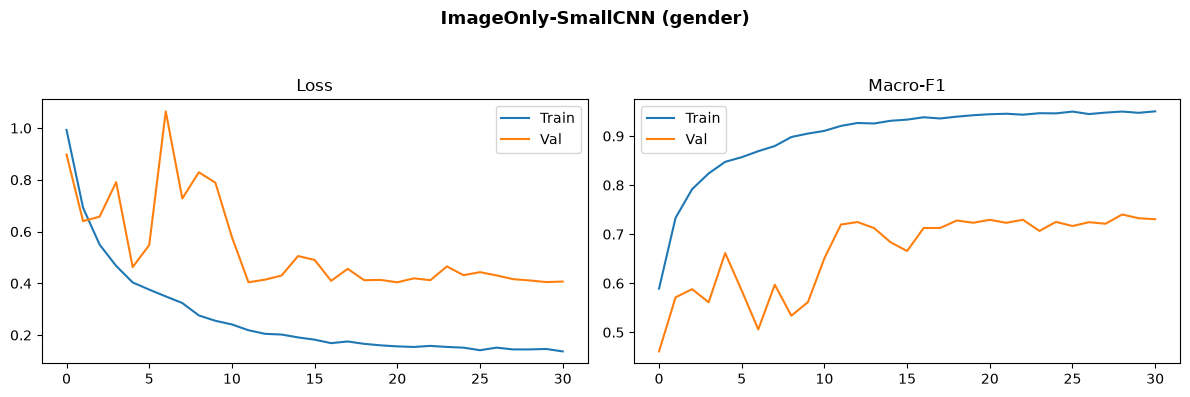

>>> ImageOnly-SmallCNN (gender): best epoch=21, train_f1=0.9445, val_f1=0.7292


ImageOnly-ImprovedSmallCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.8613  va_loss=0.6321  tr_f1=0.6573  va_f1=0.5802  lr=3.00e-04


ImageOnly-ImprovedSmallCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ImprovedSmallCNN (gender) 15/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/50 — tr_loss=0.0720  va_loss=0.4972  tr_f1=0.9762  va_f1=0.7416  lr=7.50e-05


ImageOnly-ImprovedSmallCNN (gender) 16/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (gender) 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0612  va_loss=0.4275  tr_f1=0.9793  va_f1=0.7741  lr=3.75e-05
Early stopping at epoch 16 (best epoch=6)


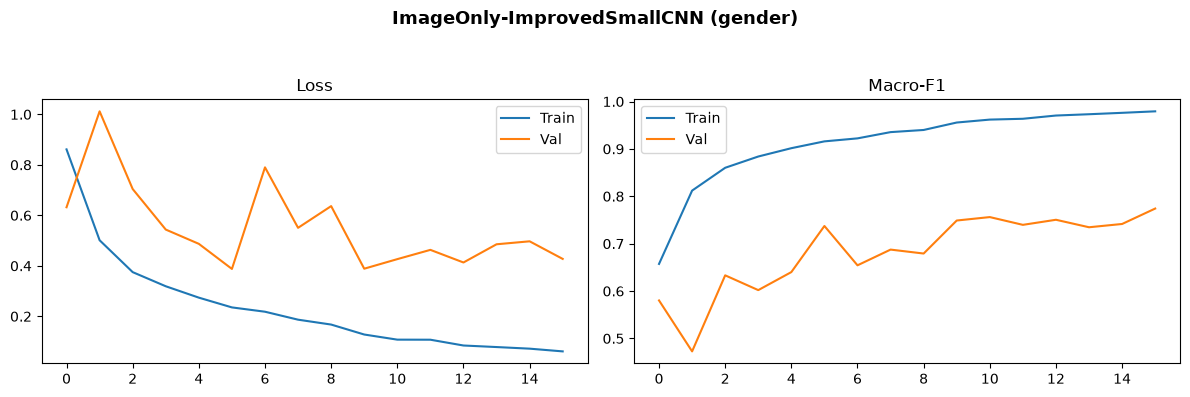

>>> ImageOnly-ImprovedSmallCNN (gender): best epoch=6, train_f1=0.9159, val_f1=0.7374


ImageOnly-SEResidualCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.9194  va_loss=0.6756  tr_f1=0.6280  va_f1=0.5371  lr=3.00e-04


ImageOnly-SEResidualCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-SEResidualCNN (gender) 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0755  va_loss=0.4277  tr_f1=0.9740  va_f1=0.7576  lr=3.75e-05


ImageOnly-SEResidualCNN (gender) 18/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (gender) 18/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 18/50 — tr_loss=0.0674  va_loss=0.4068  tr_f1=0.9763  va_f1=0.7567  lr=1.87e-05
Early stopping at epoch 18 (best epoch=8)


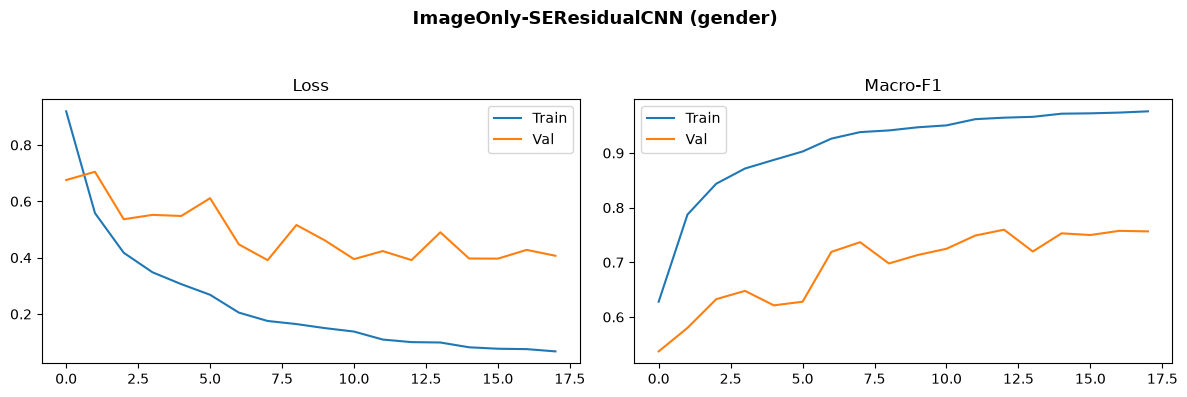

>>> ImageOnly-SEResidualCNN (gender): best epoch=8, train_f1=0.9383, val_f1=0.7369


ImageOnly-ResNet18FromScratch (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6368  va_loss=0.6905  tr_f1=0.7571  va_f1=0.5810  lr=3.00e-04


ImageOnly-ResNet18FromScratch (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18FromScratch (gender) 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.0307  va_loss=0.5229  tr_f1=0.9897  va_f1=0.7587  lr=7.50e-05


ImageOnly-ResNet18FromScratch (gender) 21/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (gender) 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0249  va_loss=0.5347  tr_f1=0.9926  va_f1=0.7639  lr=3.75e-05
Early stopping at epoch 21 (best epoch=11)


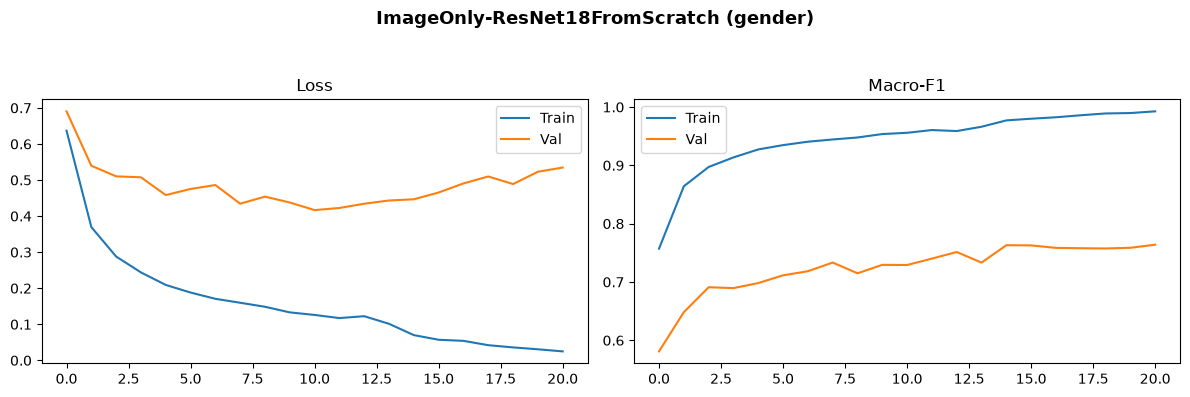

>>> ImageOnly-ResNet18FromScratch (gender): best epoch=11, train_f1=0.9558, val_f1=0.7291
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


ImageOnly-ResNet18Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4676  va_loss=0.6117  tr_f1=0.8294  va_f1=0.7063  lr=3.00e-04


...

ImageOnly-ResNet18Pretrained (gender) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0187  va_loss=0.4332  tr_f1=0.9947  va_f1=0.8014  lr=3.75e-05


ImageOnly-ResNet18Pretrained (gender) [comparison only] 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (gender) [comparison only] 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0198  va_loss=0.4557  tr_f1=0.9943  va_f1=0.7995  lr=1.87e-05
Early stopping at epoch 17 (best epoch=7)


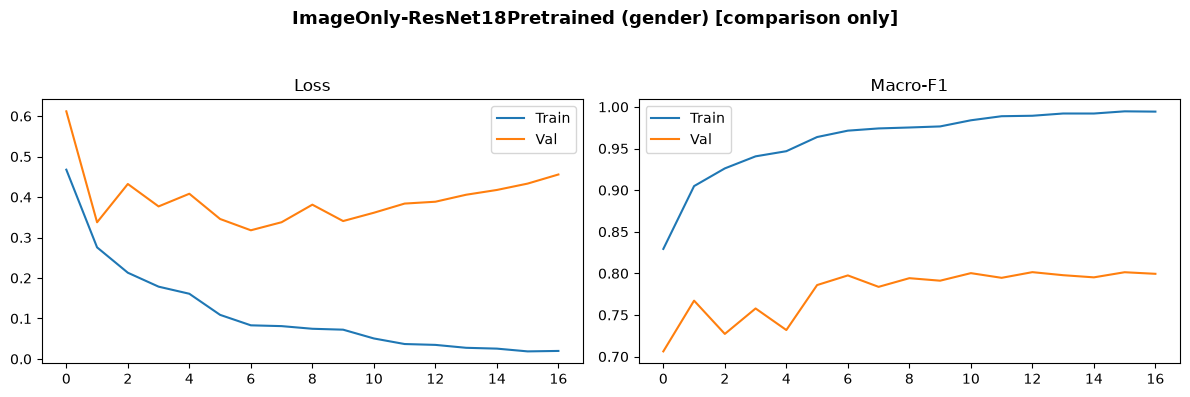

>>> ImageOnly-ResNet18Pretrained (gender) [comparison only]: best epoch=7, train_f1=0.9715, val_f1=0.7975
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 94.7MB/s]


ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6338  va_loss=0.5851  tr_f1=0.7546  va_f1=0.6305  lr=3.00e-04


...

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 19/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/50 — tr_loss=0.0525  va_loss=0.4553  tr_f1=0.9819  va_f1=0.7687  lr=3.75e-05


ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 20/50 train:   0%|          | 0/443 [00:00<?, ?it/s…

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.0477  va_loss=0.4586  tr_f1=0.9836  va_f1=0.7684  lr=1.87e-05
Early stopping at epoch 20 (best epoch=10)


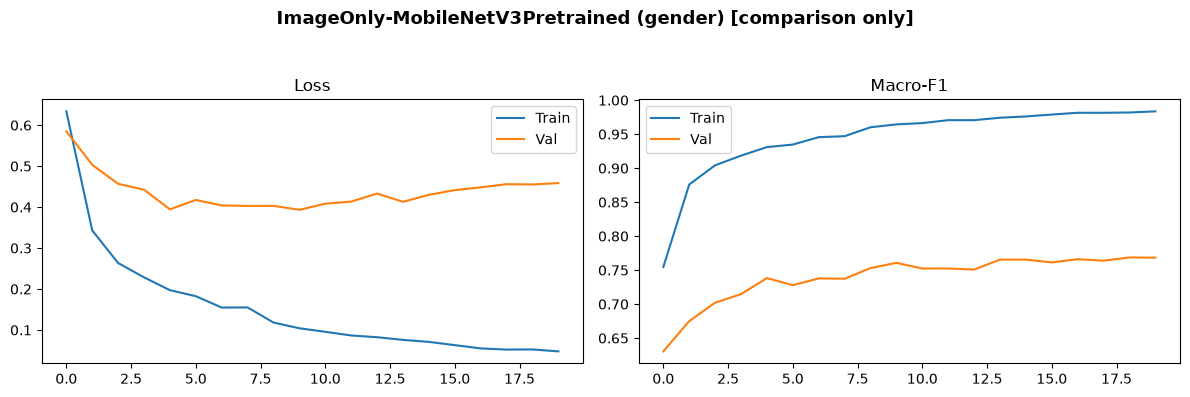

>>> ImageOnly-MobileNetV3Pretrained (gender) [comparison only]: best epoch=10, train_f1=0.9644, val_f1=0.7607


In [22]:
# ─── 9.2.1 GENDER — train all six image-only candidates ──────────────────────
torch.manual_seed(RANDOM_STATE)
gender_imgonly_basiccnn, f1_g_img_basiccnn, tr_f1_g_img_basiccnn, _ = fit(
    ImageOnlyNet(N_GENDER, SmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-SmallCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_smallcnn, f1_g_img_smallcnn, tr_f1_g_img_smallcnn, _ = fit(
    ImageOnlyNet(N_GENDER, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ImprovedSmallCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_seresnet, f1_g_img_seresnet, tr_f1_g_img_seresnet, _ = fit(
    ImageOnlyNet(N_GENDER, SEResidualImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-SEResidualCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_resnet18_scratch, f1_g_img_resnet18_scratch, tr_f1_g_img_resnet18_scratch, _ = fit(
    ImageOnlyNet(N_GENDER, ScratchResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ResNet18FromScratch (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_resnet18, f1_g_img_resnet18, tr_f1_g_img_resnet18, _ = fit(
    ImageOnlyNet(N_GENDER, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ResNet18Pretrained (gender) [comparison only]'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_mobilenet, f1_g_img_mobilenet, tr_f1_g_img_mobilenet, _ = fit(
    ImageOnlyNet(N_GENDER, PretrainedMobileNetV3Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-MobileNetV3Pretrained (gender) [comparison only]'
)


ImageOnly-SmallCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.8264  va_loss=1.0199  tr_f1=0.6890  va_f1=0.3514  lr=3.00e-04


ImageOnly-SmallCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImageOnly-SmallCNN (usage) 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.1331  va_loss=0.5398  tr_f1=0.9489  va_f1=0.4127  lr=1.87e-05


ImageOnly-SmallCNN (usage) 22/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 22/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/50 — tr_loss=0.1266  va_loss=0.5159  tr_f1=0.9505  va_f1=0.4199  lr=9.37e-06
Early stopping at epoch 22 (best epoch=12)


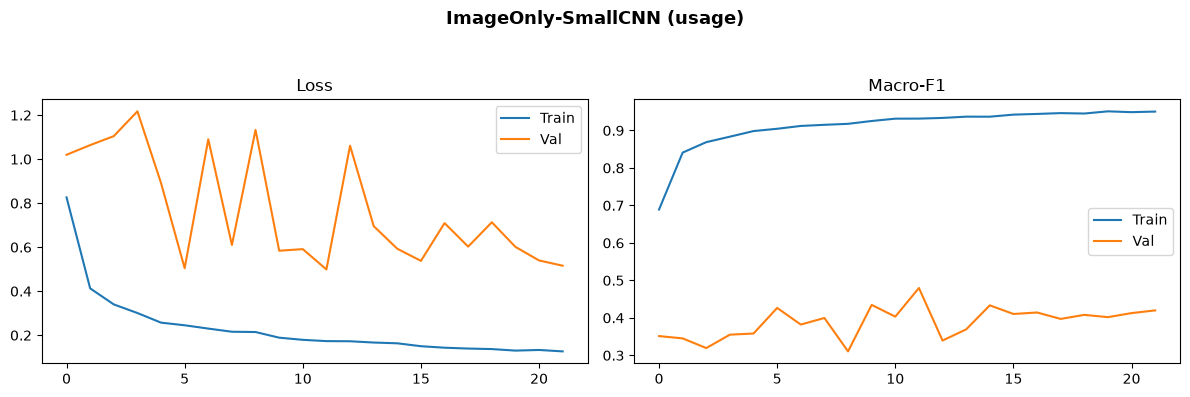

>>> ImageOnly-SmallCNN (usage): best epoch=12, train_f1=0.9317, val_f1=0.4797


ImageOnly-ImprovedSmallCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6527  va_loss=1.3236  tr_f1=0.7587  va_f1=0.2691  lr=3.00e-04


ImageOnly-ImprovedSmallCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ImprovedSmallCNN (usage) 26/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/50 — tr_loss=0.0297  va_loss=0.4597  tr_f1=0.9912  va_f1=0.4722  lr=1.87e-05


ImageOnly-ImprovedSmallCNN (usage) 27/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (usage) 27/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/50 — tr_loss=0.0248  va_loss=0.4629  tr_f1=0.9927  va_f1=0.4669  lr=9.37e-06
Early stopping at epoch 27 (best epoch=17)


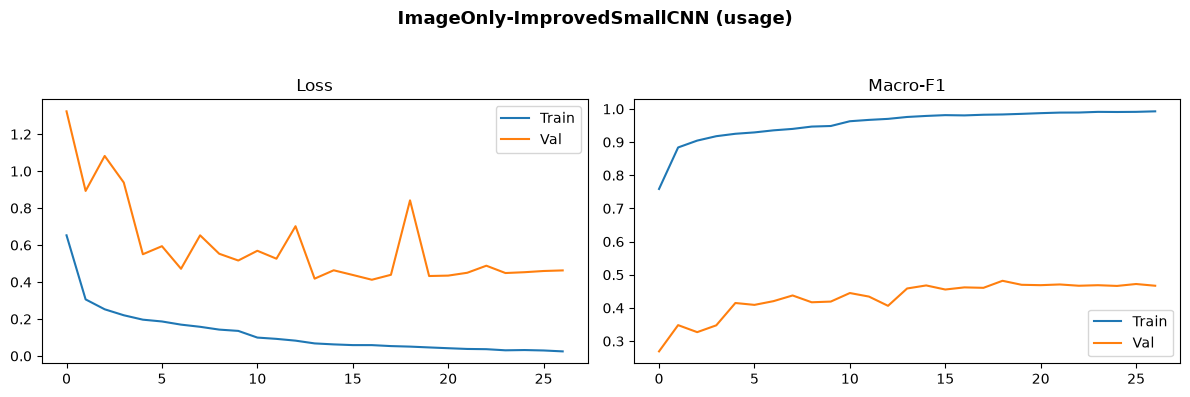

>>> ImageOnly-ImprovedSmallCNN (usage): best epoch=17, train_f1=0.9804, val_f1=0.4620


ImageOnly-SEResidualCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6961  va_loss=1.1601  tr_f1=0.7416  va_f1=0.3418  lr=3.00e-04


ImageOnly-SEResidualCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-SEResidualCNN (usage) 23/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/50 — tr_loss=0.0544  va_loss=0.4234  tr_f1=0.9825  va_f1=0.4650  lr=1.87e-05


ImageOnly-SEResidualCNN (usage) 24/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (usage) 24/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/50 — tr_loss=0.0480  va_loss=0.4309  tr_f1=0.9850  va_f1=0.4624  lr=9.37e-06
Early stopping at epoch 24 (best epoch=14)


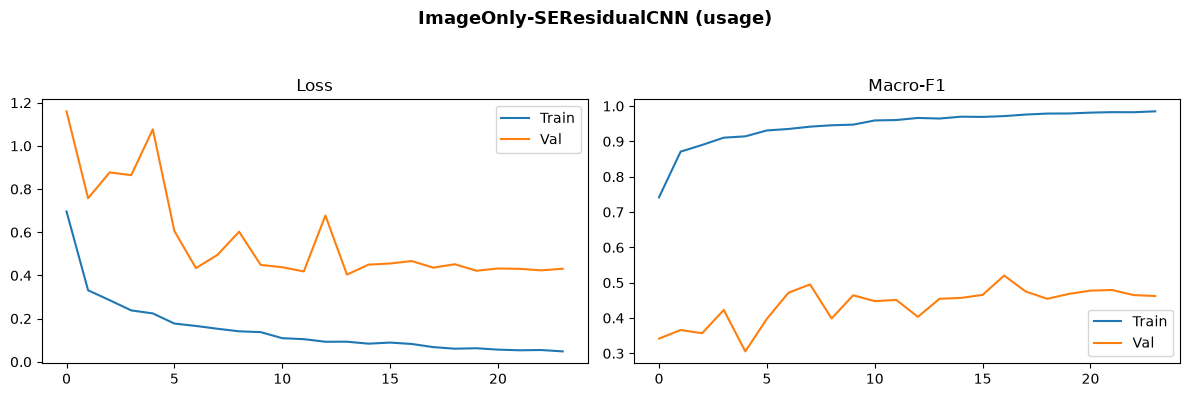

>>> ImageOnly-SEResidualCNN (usage): best epoch=14, train_f1=0.9646, val_f1=0.4545


ImageOnly-ResNet18FromScratch (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4536  va_loss=0.8979  tr_f1=0.8341  va_f1=0.3836  lr=3.00e-04


ImageOnly-ResNet18FromScratch (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18FromScratch (usage) 26/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/50 — tr_loss=0.0155  va_loss=0.6479  tr_f1=0.9957  va_f1=0.4717  lr=1.87e-05


ImageOnly-ResNet18FromScratch (usage) 27/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (usage) 27/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/50 — tr_loss=0.0169  va_loss=0.6318  tr_f1=0.9959  va_f1=0.4734  lr=9.37e-06
Early stopping at epoch 27 (best epoch=17)


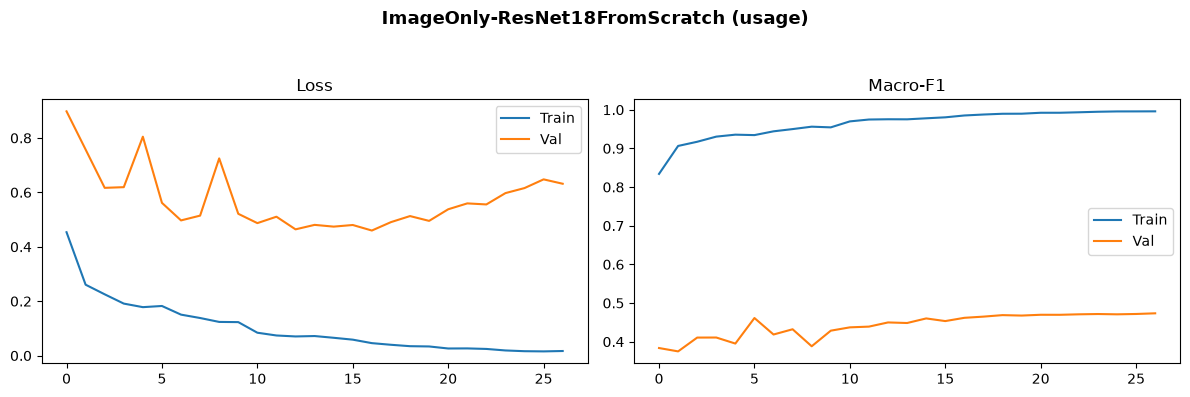

>>> ImageOnly-ResNet18FromScratch (usage): best epoch=17, train_f1=0.9852, val_f1=0.4618


ImageOnly-ResNet18Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.3530  va_loss=0.6256  tr_f1=0.8768  va_f1=0.4597  lr=3.00e-04


ImageOnly-ResNet18Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18Pretrained (usage) [comparison only] 22/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/50 — tr_loss=0.0171  va_loss=0.4933  tr_f1=0.9955  va_f1=0.4894  lr=1.87e-05


ImageOnly-ResNet18Pretrained (usage) [comparison only] 23/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (usage) [comparison only] 23/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/50 — tr_loss=0.0148  va_loss=0.4941  tr_f1=0.9962  va_f1=0.4891  lr=9.37e-06
Early stopping at epoch 23 (best epoch=13)


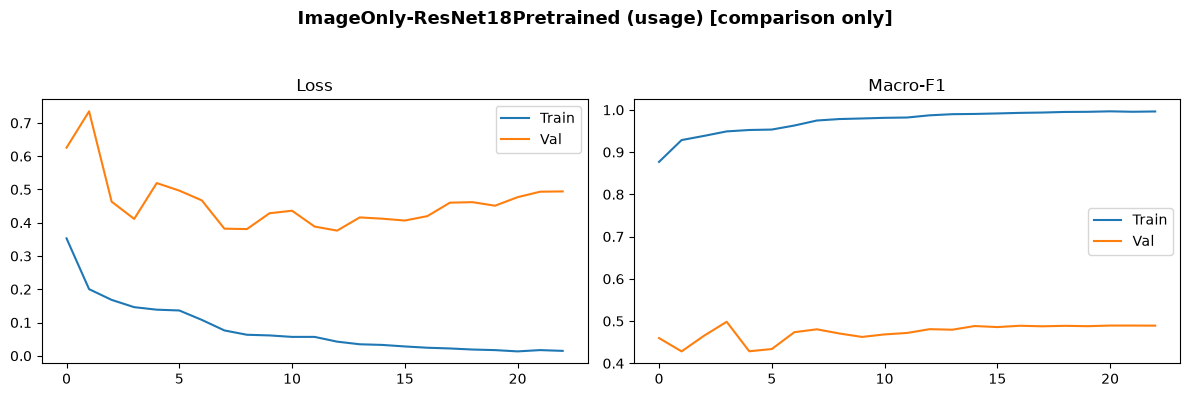

>>> ImageOnly-ResNet18Pretrained (usage) [comparison only]: best epoch=13, train_f1=0.9871, val_f1=0.4808


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4945  va_loss=0.6690  tr_f1=0.8151  va_f1=0.3882  lr=3.00e-04


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 25/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/50 — tr_loss=0.0304  va_loss=0.4601  tr_f1=0.9903  va_f1=0.4910  lr=3.75e-05


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 26/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 26/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/50 — tr_loss=0.0270  va_loss=0.4680  tr_f1=0.9919  va_f1=0.4945  lr=1.87e-05
Early stopping at epoch 26 (best epoch=16)


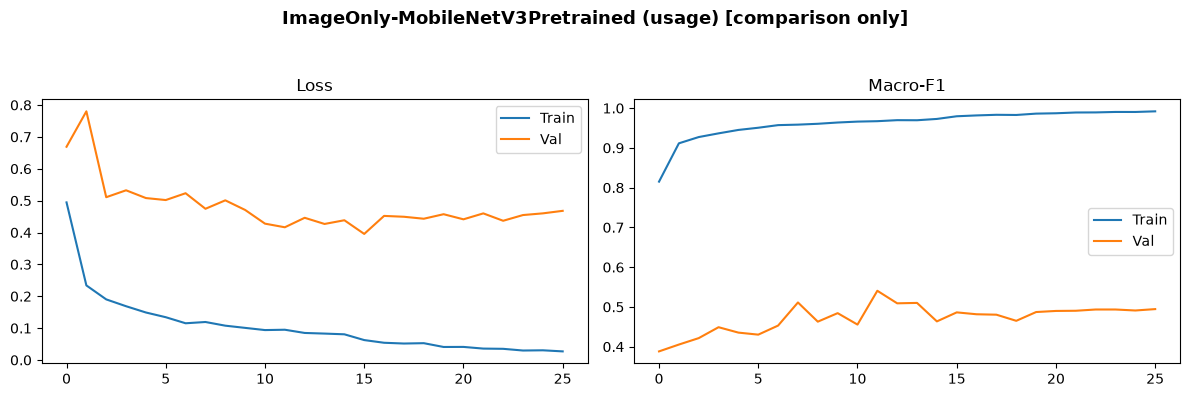

>>> ImageOnly-MobileNetV3Pretrained (usage) [comparison only]: best epoch=16, train_f1=0.9795, val_f1=0.4863


In [23]:
# ─── 9.2.2 USAGE — train all six image-only candidates ───────────────────────
torch.manual_seed(RANDOM_STATE)
usage_imgonly_basiccnn, f1_u_img_basiccnn, tr_f1_u_img_basiccnn, _ = fit(
    ImageOnlyNet(N_USAGE, SmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-SmallCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_smallcnn, f1_u_img_smallcnn, tr_f1_u_img_smallcnn, _ = fit(
    ImageOnlyNet(N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ImprovedSmallCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_seresnet, f1_u_img_seresnet, tr_f1_u_img_seresnet, _ = fit(
    ImageOnlyNet(N_USAGE, SEResidualImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-SEResidualCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_resnet18_scratch, f1_u_img_resnet18_scratch, tr_f1_u_img_resnet18_scratch, _ = fit(
    ImageOnlyNet(N_USAGE, ScratchResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ResNet18FromScratch (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_resnet18, f1_u_img_resnet18, tr_f1_u_img_resnet18, _ = fit(
    ImageOnlyNet(N_USAGE, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ResNet18Pretrained (usage) [comparison only]'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_mobilenet, f1_u_img_mobilenet, tr_f1_u_img_mobilenet, _ = fit(
    ImageOnlyNet(N_USAGE, PretrainedMobileNetV3Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-MobileNetV3Pretrained (usage) [comparison only]'
)


,Label,Model,Train Macro-F1,Val Macro-F1,From scratch
0,gender,SmallCNN (from scratch),0.9445,0.7292,True
1,gender,ImprovedSmallCNN (from scratch),0.9159,0.7374,True
2,gender,SEResidualCNN (from scratch),0.9383,0.7369,True
3,gender,ResNet18 (from scratch),0.9558,0.7291,True
4,gender,"ResNet18 (pretrained, comparison only)",0.9715,0.7975,False
5,gender,"MobileNetV3-Small (pretrained, comparison only)",0.9644,0.7607,False
6,usage,SmallCNN (from scratch),0.9317,0.4797,True
7,usage,ImprovedSmallCNN (from scratch),0.9804,0.4620,True
8,usage,SEResidualCNN (from scratch),0.9646,0.4545,True
9,usage,ResNet18 (from scratch),0.9852,0.4618,True


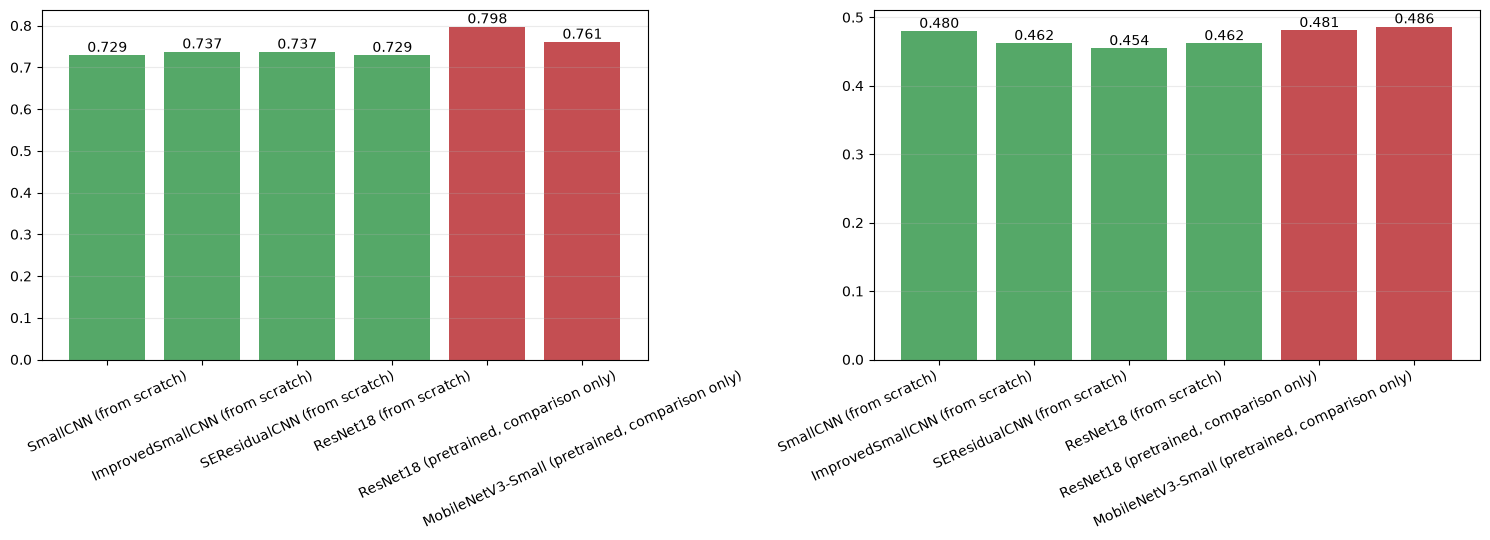

Green = from-scratch (eligible for selection).  Red = pretrained (comparison only).


In [24]:
# ─── 9.2.3 Compare candidates ─────────────────────────────────────────────────
imgonly_candidates_gender = {
    'SmallCNN (from scratch)': {
        'model': gender_imgonly_basiccnn, 'train_f1': tr_f1_g_img_basiccnn,
        'val_f1': f1_g_img_basiccnn, 'from_scratch': True},
    'ImprovedSmallCNN (from scratch)': {
        'model': gender_imgonly_smallcnn, 'train_f1': tr_f1_g_img_smallcnn,
        'val_f1': f1_g_img_smallcnn, 'from_scratch': True},
    'SEResidualCNN (from scratch)': {
        'model': gender_imgonly_seresnet, 'train_f1': tr_f1_g_img_seresnet,
        'val_f1': f1_g_img_seresnet, 'from_scratch': True},
    'ResNet18 (from scratch)': {
        'model': gender_imgonly_resnet18_scratch, 'train_f1': tr_f1_g_img_resnet18_scratch,
        'val_f1': f1_g_img_resnet18_scratch, 'from_scratch': True},
    'ResNet18 (pretrained, comparison only)': {
        'model': gender_imgonly_resnet18, 'train_f1': tr_f1_g_img_resnet18,
        'val_f1': f1_g_img_resnet18, 'from_scratch': False},
    'MobileNetV3-Small (pretrained, comparison only)': {
        'model': gender_imgonly_mobilenet, 'train_f1': tr_f1_g_img_mobilenet,
        'val_f1': f1_g_img_mobilenet, 'from_scratch': False},
}

imgonly_candidates_usage = {
    'SmallCNN (from scratch)': {
        'model': usage_imgonly_basiccnn, 'train_f1': tr_f1_u_img_basiccnn,
        'val_f1': f1_u_img_basiccnn, 'from_scratch': True},
    'ImprovedSmallCNN (from scratch)': {
        'model': usage_imgonly_smallcnn, 'train_f1': tr_f1_u_img_smallcnn,
        'val_f1': f1_u_img_smallcnn, 'from_scratch': True},
    'SEResidualCNN (from scratch)': {
        'model': usage_imgonly_seresnet, 'train_f1': tr_f1_u_img_seresnet,
        'val_f1': f1_u_img_seresnet, 'from_scratch': True},
    'ResNet18 (from scratch)': {
        'model': usage_imgonly_resnet18_scratch, 'train_f1': tr_f1_u_img_resnet18_scratch,
        'val_f1': f1_u_img_resnet18_scratch, 'from_scratch': True},
    'ResNet18 (pretrained, comparison only)': {
        'model': usage_imgonly_resnet18, 'train_f1': tr_f1_u_img_resnet18,
        'val_f1': f1_u_img_resnet18, 'from_scratch': False},
    'MobileNetV3-Small (pretrained, comparison only)': {
        'model': usage_imgonly_mobilenet, 'train_f1': tr_f1_u_img_mobilenet,
        'val_f1': f1_u_img_mobilenet, 'from_scratch': False},
}

imgonly_results_df = pd.DataFrame(
    [{'Label': 'gender', 'Model': name, 'Train Macro-F1': v['train_f1'],
      'Val Macro-F1': v['val_f1'], 'From scratch': v['from_scratch']}
     for name, v in imgonly_candidates_gender.items()]
    +
    [{'Label': 'usage', 'Model': name, 'Train Macro-F1': v['train_f1'],
      'Val Macro-F1': v['val_f1'], 'From scratch': v['from_scratch']}
     for name, v in imgonly_candidates_usage.items()]
)
display(imgonly_results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, candidates, title in zip(
        axes,
        [imgonly_candidates_gender, imgonly_candidates_usage],
        ['Gender — image-only candidates', 'Usage — image-only candidates']):
    names      = list(candidates.keys())
    val_scores = [candidates[n]['val_f1'] for n in names]
    colors     = ['#55A868' if candidates[n]['from_scratch'] else '#C44E52' for n in names]
    bars = ax.bar(names, val_scores, color=colors)
    ax.tick_params(axis='x', rotation=25)

    ax.bar_label(bars, fmt='%.3f')
    ax.grid(axis='y', alpha=0.25)
plt.setp(ax.get_xticklabels(), ha='right')
plt.tight_layout(); plt.show()
print('Green = from-scratch (eligible for selection).  Red = pretrained (comparison only).')


In [25]:
# ─── 9.2.4 Pick the best FROM-SCRATCH-eligible image-only model, per label ────
# Same "fully train your own" rule as everywhere else in this notebook (see
# 9.4/9.6): pretrained backbones are shown above for comparison but can never
# be the model that gets saved/submitted.
def pick_best_image_only(candidates):
    eligible  = {name: v for name, v in candidates.items() if v['from_scratch']}
    best_name = max(eligible, key=lambda n: eligible[n]['val_f1'])
    return best_name, eligible[best_name]

best_gender_imgonly_name, best_gender_imgonly = pick_best_image_only(imgonly_candidates_gender)
best_usage_imgonly_name,  best_usage_imgonly  = pick_best_image_only(imgonly_candidates_usage)

print(f"Best from-scratch image-only GENDER model: {best_gender_imgonly_name}  "
      f"(val Macro-F1={best_gender_imgonly['val_f1']:.4f})")
print(f"Best from-scratch image-only USAGE model:  {best_usage_imgonly_name}  "
      f"(val Macro-F1={best_usage_imgonly['val_f1']:.4f})")

IMAGEONLY_DIR = OUTPUT_DIR / 'image_only'
IMAGEONLY_DIR.mkdir(exist_ok=True)

torch.save(best_gender_imgonly['model'].state_dict(), IMAGEONLY_DIR / 'gender_imageonly_best.pt')
torch.save(best_usage_imgonly['model'].state_dict(),  IMAGEONLY_DIR / 'usage_imageonly_best.pt')

with open(IMAGEONLY_DIR / 'image_only_best_manifest.txt', 'w') as f:
    f.write(f"gender: {best_gender_imgonly_name}  val_macro_f1={best_gender_imgonly['val_f1']:.4f}\n")
    f.write(f"usage:  {best_usage_imgonly_name}  val_macro_f1={best_usage_imgonly['val_f1']:.4f}\n")

print(f"\nSaved best image-only models to {IMAGEONLY_DIR}:")
for f in sorted(IMAGEONLY_DIR.iterdir()):
    print(f"  {f.name}")


Best from-scratch image-only GENDER model: ImprovedSmallCNN (from scratch)  (val Macro-F1=0.7374)
Best from-scratch image-only USAGE model:  SmallCNN (from scratch)  (val Macro-F1=0.4797)

Saved best image-only models to ../outputs/task3_models/image_only:
  gender_imageonly_best.pt
  image_only_best_manifest.txt
  usage_imageonly_best.pt


#### 9.2.5 From-scratch vs. pretrained — quantifying the gap

The table and bar chart in 9.2.3 already show every candidate side by side; the cell below just
isolates the two extremes — the best **from-scratch** candidate (green bars) against the best
**pretrained** candidate (red bars) — and prints the actual gap for each label.

A pretrained backbone starts with ImageNet features (edges, textures, shapes) that this dataset
alone likely isn't large enough to relearn from scratch, so it's normal for the pretrained models
to edge out the from-scratch ones here. What matters for this assignment is less "did pretrained
win" and more "by how much" — a small gap says the from-scratch encoder is capturing most of the
useful signal on its own; a large gap says the fused multi-input models below are leaning more on
raw pixels than on the from-scratch architecture's inductive bias.

In [26]:
# ─── 9.2.5 From-scratch vs. pretrained (image-only), per label ───────────────
def best_of(candidates, from_scratch):
    pool = {name: v for name, v in candidates.items() if v['from_scratch'] == from_scratch}
    name = max(pool, key=lambda n: pool[n]['val_f1'])
    return name, pool[name]

best_gender_pretrained_name, best_gender_pretrained = best_of(imgonly_candidates_gender, False)
best_usage_pretrained_name,  best_usage_pretrained  = best_of(imgonly_candidates_usage,  False)

gap_gender = best_gender_pretrained['val_f1'] - best_gender_imgonly['val_f1']
gap_usage  = best_usage_pretrained['val_f1']  - best_usage_imgonly['val_f1']

print('GENDER —', f"from-scratch best: {best_gender_imgonly_name} (val F1={best_gender_imgonly['val_f1']:.4f})  "
      f"vs. pretrained best: {best_gender_pretrained_name} (val F1={best_gender_pretrained['val_f1']:.4f})")
print(f"  → pretrained {'leads' if gap_gender > 0 else 'trails'} by {abs(gap_gender):.4f} Macro-F1\n")

print('USAGE  —', f"from-scratch best: {best_usage_imgonly_name} (val F1={best_usage_imgonly['val_f1']:.4f})  "
      f"vs. pretrained best: {best_usage_pretrained_name} (val F1={best_usage_pretrained['val_f1']:.4f})")
print(f"  → pretrained {'leads' if gap_usage > 0 else 'trails'} by {abs(gap_usage):.4f} Macro-F1")


GENDER — from-scratch best: ImprovedSmallCNN (from scratch) (val F1=0.7374)  vs. pretrained best: ResNet18 (pretrained, comparison only) (val F1=0.7975)
  → pretrained leads by 0.0602 Macro-F1

USAGE  — from-scratch best: SmallCNN (from scratch) (val F1=0.4797)  vs. pretrained best: MobileNetV3-Small (pretrained, comparison only) (val F1=0.4863)
  → pretrained leads by 0.0066 Macro-F1


#### 9.2.6 Carrying the winning from-scratch encoder into the multi-input models

Task 2's multi-input models always used a fixed `ImprovedSmallImageEncoder` image branch. From
here on, the multi-input classifiers (9.3, 9.5) and the gated-fusion models (9.7) instead plug in
whichever from-scratch encoder actually won 9.2 for that label — `BestGenderImageEncoder` for
gender, `BestUsageImageEncoder` for usage — so the fused result reflects the strongest
single-image architecture rather than one picked out of habit. The two are resolved below.

In [27]:
# ─── 9.2.6 Resolve the winning encoder class per label ───────────────────────
IMAGE_ENCODER_CLASSES = {
    'SmallCNN (from scratch)':         SmallImageEncoder,
    'ImprovedSmallCNN (from scratch)': ImprovedSmallImageEncoder,
    'SEResidualCNN (from scratch)':    SEResidualImageEncoder,
    'ResNet18 (from scratch)':         ScratchResNet18Encoder,
}

BestGenderImageEncoder = IMAGE_ENCODER_CLASSES[best_gender_imgonly_name]
BestUsageImageEncoder  = IMAGE_ENCODER_CLASSES[best_usage_imgonly_name]
GENDER_ENCODER_NAME    = BestGenderImageEncoder.__name__
USAGE_ENCODER_NAME     = BestUsageImageEncoder.__name__

print(f"Multi-input GENDER models (9.3, 9.7) will use {GENDER_ENCODER_NAME} "
      f"(winner of the 9.2 image-only comparison for gender).")
print(f"Multi-input USAGE  models (9.5, 9.7) will use {USAGE_ENCODER_NAME} "
      f"(winner of the 9.2 image-only comparison for usage).")


Multi-input GENDER models (9.3, 9.7) will use ImprovedSmallImageEncoder (winner of the 9.2 image-only comparison for gender).
Multi-input USAGE  models (9.5, 9.7) will use SmallImageEncoder (winner of the 9.2 image-only comparison for usage).


---
## Part 2 — Multi-input models begin here (9.3–9.8)

Every model below sees **both** the product image and the tabular metadata for each sample —
unlike 9.1 (metadata only) and 9.2 (image only) above. `BestGenderImageEncoder` /
`BestUsageImageEncoder` (resolved in 9.2.6) supply the image branch throughout, so these results
reflect the strongest from-scratch architecture found for each label rather than a fixed choice.

MultiInput-ImprovedSmallImageEncoder (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedSmallImageEncoder (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.7017  va_loss=0.7601  tr_f1=0.7348  va_f1=0.5474  lr=3.00e-04


MultiInput-ImprovedSmallImageEncoder (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedSmallImageEncoder (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallImageEncoder (gender) 23/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/50 — tr_loss=0.0306  va_loss=0.4473  tr_f1=0.9901  va_f1=0.8217  lr=1.87e-05


MultiInput-ImprovedSmallImageEncoder (gender) 24/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedSmallImageEncoder (gender) 24/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/50 — tr_loss=0.0299  va_loss=0.4667  tr_f1=0.9903  va_f1=0.8133  lr=9.37e-06
Early stopping at epoch 24 (best epoch=14)


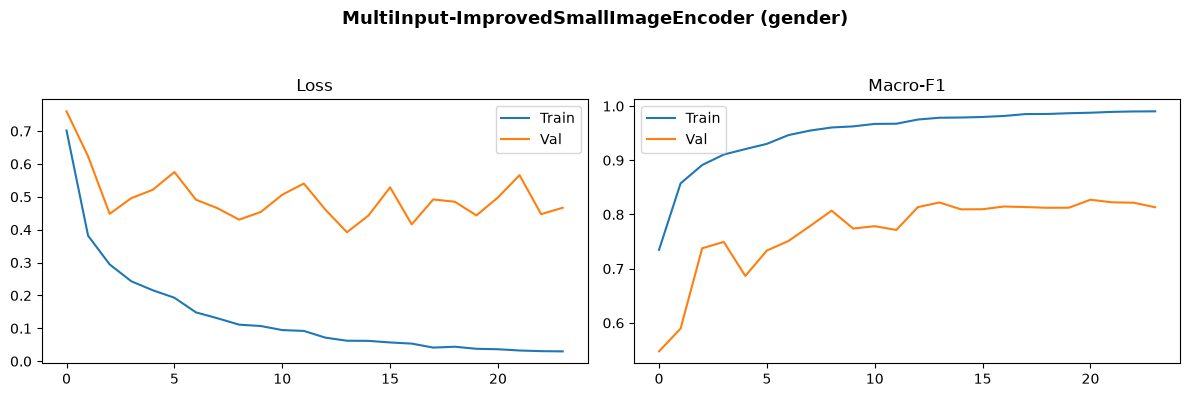

>>> MultiInput-ImprovedSmallImageEncoder (gender): best epoch=14, train_f1=0.9785, val_f1=0.8222
Saved gender model (ImprovedSmallImageEncoder) — train_f1=0.9785  val_f1=0.8222


In [28]:
# ─── 9.3 Gender classifier — MultiInput + Best From-Scratch Image Encoder ────
# Image branch = BestGenderImageEncoder, resolved in 9.2.6 (the from-scratch
# architecture that won the 9.2 image-only comparison for gender).
train_ds_gender = MultiInputDataset(train_data, meta_train, y_gender_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_gender   = MultiInputDataset(val_data,   meta_val,   y_gender_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_gender = DataLoader(train_ds_gender, batch_size=BATCH_SIZE, sampler=sampler_gender,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_gender   = DataLoader(val_ds_gender,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
gender_model, gender_f1, gender_train_f1, gender_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, BestGenderImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name=f'MultiInput-{GENDER_ENCODER_NAME} (gender)'
)

torch.save(gender_model.state_dict(), OUTPUT_DIR / 'gender_multiinput_smallcnn.pt')
print(f'Saved gender model ({GENDER_ENCODER_NAME}) — train_f1={gender_train_f1:.4f}  val_f1={gender_f1:.4f}')


MultiInput-ResNet18Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4556  va_loss=0.4077  tr_f1=0.8320  va_f1=0.7600  lr=3.00e-04


MultiInput-ResNet18Pretrained (gender) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (gender) [comparison only] 15/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/50 — tr_loss=0.0193  va_loss=0.3590  tr_f1=0.9943  va_f1=0.8457  lr=3.75e-05


MultiInput-ResNet18Pretrained (gender) [comparison only] 16/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0151  va_loss=0.4729  tr_f1=0.9955  va_f1=0.8289  lr=1.87e-05
Early stopping at epoch 16 (best epoch=6)


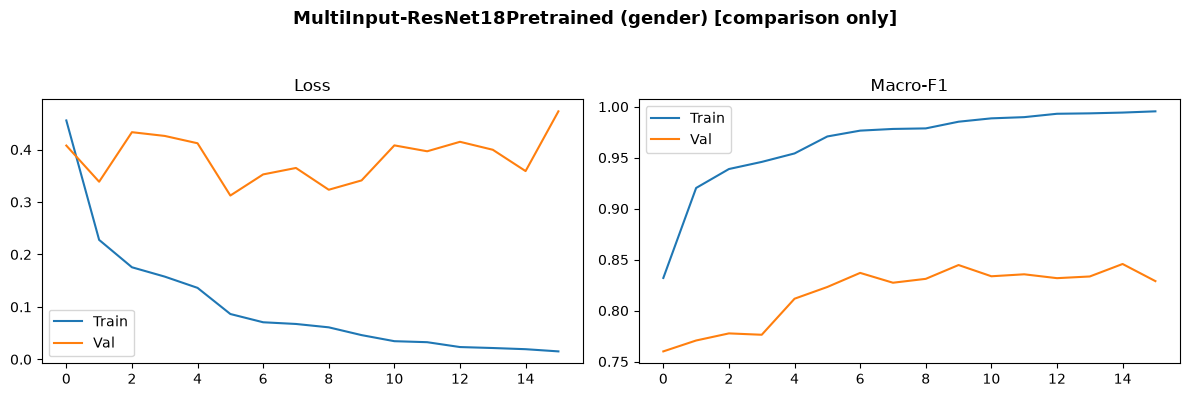

>>> MultiInput-ResNet18Pretrained (gender) [comparison only]: best epoch=6, train_f1=0.9708, val_f1=0.8232
Pretrained ResNet18 gender (comparison only) — train_f1=0.9708  val_f1=0.8232


In [29]:
# ─── 9.4 Gender classifier — MultiInput + Pretrained ResNet18 ────────────────
# NOTE: this backbone is ImageNet-pretrained (see PretrainedResNet18Encoder in
# Section 8). The assignment spec requires the FINAL/submitted model to be
# fully trained from scratch, and only allows pretrained models "for
# comparison". This model is therefore kept in the results table/bar chart
# below for comparison, but is explicitly EXCLUDED from best-model selection
# in Section 12 (see the "from-scratch only" candidate dict there).
torch.manual_seed(RANDOM_STATE)
gender_resnet_model, gender_resnet_f1, gender_resnet_train_f1, gender_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='MultiInput-ResNet18Pretrained (gender) [comparison only]'
)
print(f'Pretrained ResNet18 gender (comparison only) — train_f1={gender_resnet_train_f1:.4f}  val_f1={gender_resnet_f1:.4f}')


MultiInput-SmallImageEncoder (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-SmallImageEncoder (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.5775  va_loss=0.6473  tr_f1=0.8051  va_f1=0.4458  lr=3.00e-04


MultiInput-SmallImageEncoder (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-SmallImageEncoder (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-SmallImageEncoder (usage) 31/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 31/50 — tr_loss=0.0598  va_loss=0.4302  tr_f1=0.9795  va_f1=0.5462  lr=4.69e-06


MultiInput-SmallImageEncoder (usage) 32/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-SmallImageEncoder (usage) 32/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 32/50 — tr_loss=0.0604  va_loss=0.4424  tr_f1=0.9793  va_f1=0.5996  lr=2.34e-06
Early stopping at epoch 32 (best epoch=22)


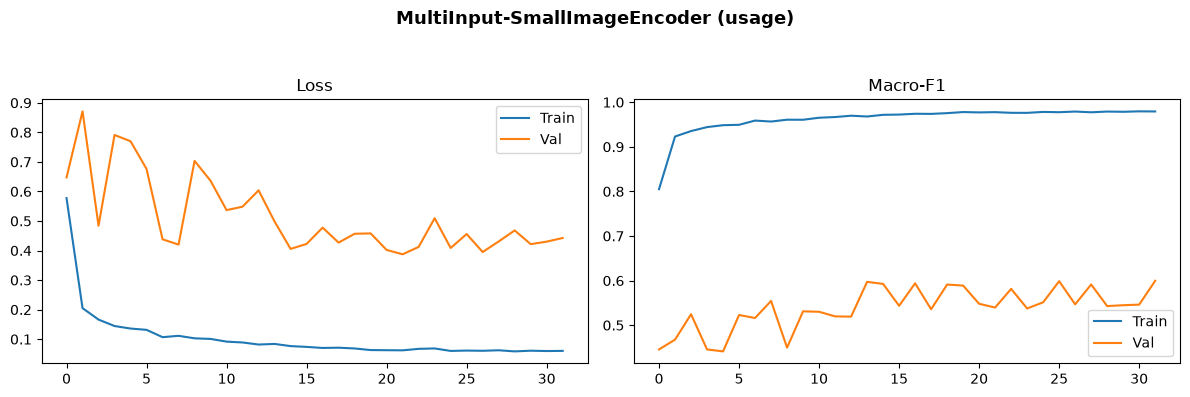

>>> MultiInput-SmallImageEncoder (usage): best epoch=22, train_f1=0.9777, val_f1=0.5396
Saved usage model (SmallImageEncoder) — train_f1=0.9777  val_f1=0.5396


In [30]:
# ─── 9.5 Usage classifier — MultiInput + Best From-Scratch Image Encoder ─────
# Image branch = BestUsageImageEncoder, resolved in 9.2.6 (the from-scratch
# architecture that won the 9.2 image-only comparison for usage).
train_ds_usage = MultiInputDataset(train_data, meta_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_usage   = MultiInputDataset(val_data,   meta_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_usage = DataLoader(train_ds_usage, batch_size=BATCH_SIZE, sampler=sampler_usage,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_usage   = DataLoader(val_ds_usage,   batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
usage_model, usage_f1, usage_train_f1, usage_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, BestUsageImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name=f'MultiInput-{USAGE_ENCODER_NAME} (usage)'
)

torch.save(usage_model.state_dict(), OUTPUT_DIR / 'usage_multiinput_smallcnn.pt')
print(f'Saved usage model ({USAGE_ENCODER_NAME}) — train_f1={usage_train_f1:.4f}  val_f1={usage_f1:.4f}')


MultiInput-ResNet18Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.3149  va_loss=0.3752  tr_f1=0.8921  va_f1=0.4768  lr=3.00e-04


MultiInput-ResNet18Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (usage) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0183  va_loss=0.4197  tr_f1=0.9952  va_f1=0.5128  lr=3.75e-05


MultiInput-ResNet18Pretrained (usage) [comparison only] 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0158  va_loss=0.4984  tr_f1=0.9957  va_f1=0.5140  lr=1.87e-05
Early stopping at epoch 17 (best epoch=7)


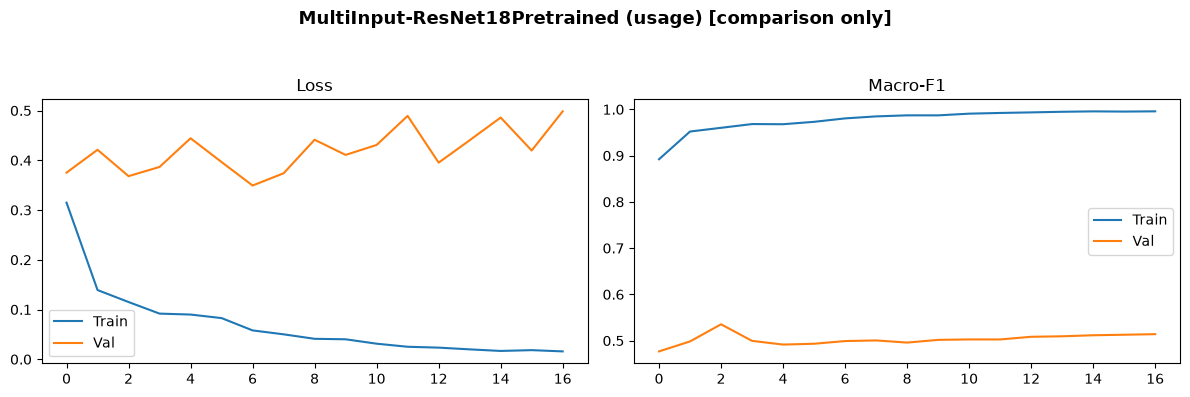

>>> MultiInput-ResNet18Pretrained (usage) [comparison only]: best epoch=7, train_f1=0.9804, val_f1=0.4991
Pretrained ResNet18 usage (comparison only) — train_f1=0.9804  val_f1=0.4991


In [31]:
# ─── 9.6 Usage classifier — MultiInput + Pretrained ResNet18 ─────────────────
# NOTE: comparison-only — see the note in 9.4. Excluded from best-model
# selection in Section 12.
torch.manual_seed(RANDOM_STATE)
usage_resnet_model, usage_resnet_f1, usage_resnet_train_f1, usage_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='MultiInput-ResNet18Pretrained (usage) [comparison only]'
)
print(f'Pretrained ResNet18 usage (comparison only) — train_f1={usage_resnet_train_f1:.4f}  val_f1={usage_resnet_f1:.4f}')


### 9.7 Second fusion strategy — Gated Fusion (image + metadata)

Concatenation (used by `MultiInputNet` above) always weighs both modalities equally. Gated
fusion lets the model learn, per sample, how much to rely on the image vs. the metadata branch.
This is the additional fusion strategy investigated beyond plain concatenation.

GatedFusion-ImprovedSmallImageEncoder (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedSmallImageEncoder (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.7340  va_loss=0.5100  tr_f1=0.7118  va_f1=0.7057  lr=3.00e-04


GatedFusion-ImprovedSmallImageEncoder (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedSmallImageEncoder (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

GatedFusion-ImprovedSmallImageEncoder (gender) 25/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/50 — tr_loss=0.0405  va_loss=0.5458  tr_f1=0.9866  va_f1=0.8246  lr=9.37e-06


GatedFusion-ImprovedSmallImageEncoder (gender) 26/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedSmallImageEncoder (gender) 26/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/50 — tr_loss=0.0361  va_loss=0.5424  tr_f1=0.9875  va_f1=0.8229  lr=4.69e-06
Early stopping at epoch 26 (best epoch=16)


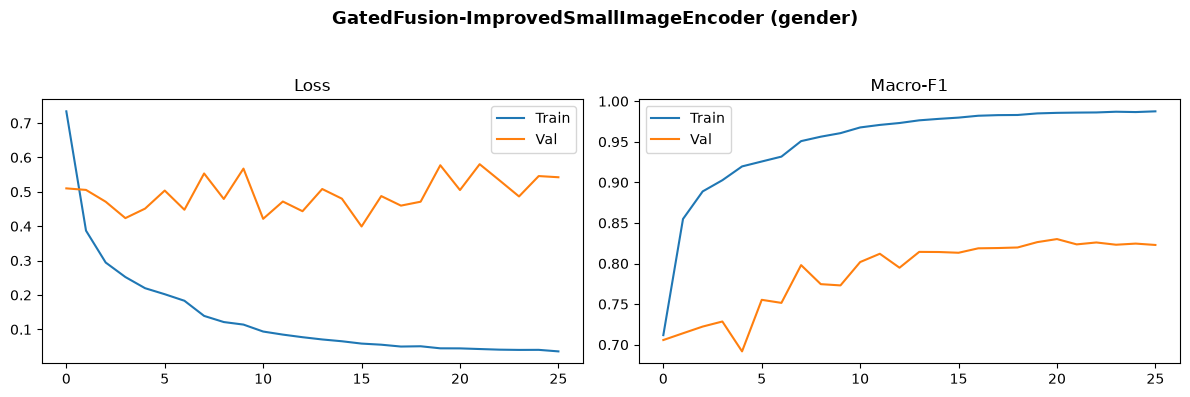

>>> GatedFusion-ImprovedSmallImageEncoder (gender): best epoch=16, train_f1=0.9798, val_f1=0.8133
Saved gated-fusion gender model (ImprovedSmallImageEncoder) — train_f1=0.9798  val_f1=0.8133


In [32]:
# Image branch = BestGenderImageEncoder (same winning encoder as 9.3).
torch.manual_seed(RANDOM_STATE)
gender_gated_model, gender_gated_f1, gender_gated_train_f1, gender_gated_epoch = fit(
    GatedFusionNet(META_DIM, N_GENDER, BestGenderImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name=f'GatedFusion-{GENDER_ENCODER_NAME} (gender)'
)

torch.save(gender_gated_model.state_dict(), OUTPUT_DIR / 'gender_gatedfusion.pt')
print(f'Saved gated-fusion gender model ({GENDER_ENCODER_NAME}) — train_f1={gender_gated_train_f1:.4f}  val_f1={gender_gated_f1:.4f}')

GatedFusion-SmallImageEncoder (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-SmallImageEncoder (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6215  va_loss=0.7237  tr_f1=0.7761  va_f1=0.4640  lr=3.00e-04


GatedFusion-SmallImageEncoder (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-SmallImageEncoder (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

GatedFusion-SmallImageEncoder (usage) 18/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 18/50 — tr_loss=0.0718  va_loss=0.3694  tr_f1=0.9728  va_f1=0.5651  lr=3.75e-05


GatedFusion-SmallImageEncoder (usage) 19/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-SmallImageEncoder (usage) 19/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/50 — tr_loss=0.0715  va_loss=0.3661  tr_f1=0.9755  va_f1=0.5355  lr=1.87e-05
Early stopping at epoch 19 (best epoch=9)


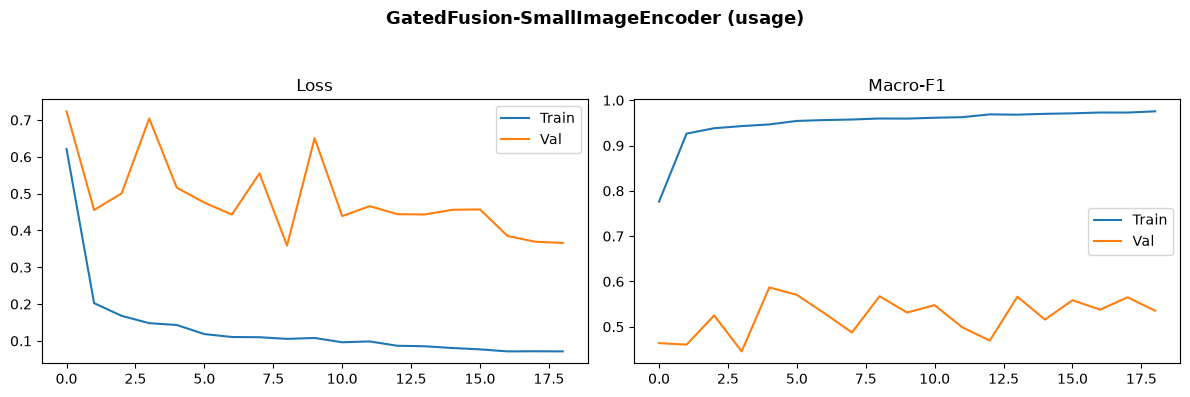

>>> GatedFusion-SmallImageEncoder (usage): best epoch=9, train_f1=0.9597, val_f1=0.5674
Saved gated-fusion usage model (SmallImageEncoder) — train_f1=0.9597  val_f1=0.5674


In [33]:
# Image branch = BestUsageImageEncoder (same winning encoder as 9.5).
torch.manual_seed(RANDOM_STATE)
usage_gated_model, usage_gated_f1, usage_gated_train_f1, usage_gated_epoch = fit(
    GatedFusionNet(META_DIM, N_USAGE, BestUsageImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name=f'GatedFusion-{USAGE_ENCODER_NAME} (usage)'
)

torch.save(usage_gated_model.state_dict(), OUTPUT_DIR / 'usage_gatedfusion.pt')
print(f'Saved gated-fusion usage model ({USAGE_ENCODER_NAME}) — train_f1={usage_gated_train_f1:.4f}  val_f1={usage_gated_f1:.4f}')

### 9.8 Soft-voting ensemble (LogReg ⊕ best from-scratch MultiInput model) — no extra training

An unweighted (50/50) soft vote between the metadata-only LogReg baseline (9.1) and the
image+metadata MultiInput model from 9.3/9.5 — whichever from-scratch image encoder that
happened to win for each label — computed directly from probabilities already produced by models
trained above. No new network is trained for this model.

In [34]:
def get_cnn_probs(model, loader):
    """Softmax probabilities from a MultiInputNet-style model, in loader order
    (loader must have shuffle=False so the order lines up with a metadata array)."""
    model.eval(); probs = []
    with torch.no_grad():
        for batch in loader:
            inputs, _ = to_device(batch)
            probs.append(torch.softmax(model(*inputs), dim=1).cpu().numpy())
    return np.concatenate(probs, axis=0)

# Eval-mode (shuffle=False, no weighted sampler) loaders so CNN output order
# matches the plain row order of meta_train / meta_val used by LogReg.
train_loader_gender_eval = DataLoader(train_ds_gender, batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
train_loader_usage_eval  = DataLoader(train_ds_usage,  batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

def soft_vote_f1(cnn_model, logreg_model, loader, meta, y_true):
    cnn_probs    = get_cnn_probs(cnn_model, loader)
    logreg_probs = logreg_model.predict_proba(meta)
    vote_probs   = 0.5 * cnn_probs + 0.5 * logreg_probs
    preds        = vote_probs.argmax(1)
    return f1_score(y_true, preds, average='macro', zero_division=0)

f1_g_softvote_train = soft_vote_f1(gender_model, logreg_gender, train_loader_gender_eval, meta_train, y_gender_train)
f1_g_softvote       = soft_vote_f1(gender_model, logreg_gender, val_loader_gender,        meta_val,   y_gender_val)
f1_u_softvote_train = soft_vote_f1(usage_model,  logreg_usage,  train_loader_usage_eval,  meta_train, y_usage_train)
f1_u_softvote       = soft_vote_f1(usage_model,  logreg_usage,  val_loader_usage,         meta_val,   y_usage_val)

print(f'Soft-voting ensemble — gender: train_f1={f1_g_softvote_train:.4f}  val_f1={f1_g_softvote:.4f}')
print(f'Soft-voting ensemble — usage:  train_f1={f1_u_softvote_train:.4f}  val_f1={f1_u_softvote:.4f}')

Soft-voting ensemble — gender: train_f1=0.9307  val_f1=0.8158
Soft-voting ensemble — usage:  train_f1=0.6655  val_f1=0.5343


## 10. Approach B — Single combined-label classifier (gender × usage)

Treats gender_usage as one combined class. Learns the joint distribution but has more classes and sparser per-class data.

MultiInput-ImprovedCNN (gender x usage combined) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=1.1685  va_loss=1.2100  tr_f1=0.6355  va_f1=0.3912  lr=3.00e-04


MultiInput-ImprovedCNN (gender x usage combined) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (gender x usage combined) 27/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/50 — tr_loss=0.0467  va_loss=1.0569  tr_f1=0.9858  va_f1=0.5707  lr=1.87e-05


MultiInput-ImprovedCNN (gender x usage combined) 28/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 28/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 28/50 — tr_loss=0.0434  va_loss=0.9359  tr_f1=0.9858  va_f1=0.5814  lr=9.37e-06
Early stopping at epoch 28 (best epoch=18)


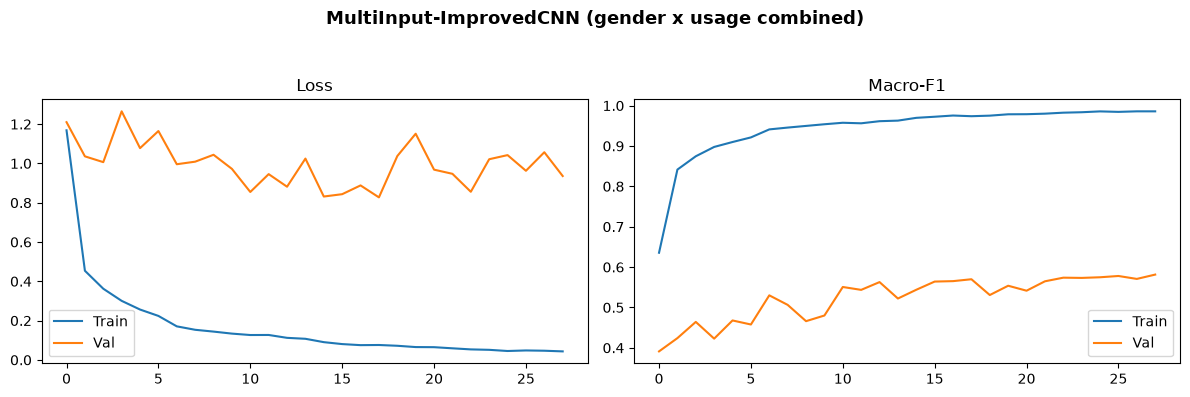

>>> MultiInput-ImprovedCNN (gender x usage combined): best epoch=18, train_f1=0.9737, val_f1=0.5699
Saved combined model — train_f1(joint)=0.9737  val_f1(joint)=0.5699


In [35]:
y_combined_train = train_data['gender_usage_label'].values
y_combined_val   = val_data['gender_usage_label'].values
sampler_combined = get_weighted_sampler(train_data, 'gender_usage_label')

train_ds_combined = MultiInputDataset(train_data, meta_train, y_combined_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_combined   = MultiInputDataset(val_data,   meta_val,   y_combined_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_combined = DataLoader(train_ds_combined, batch_size=BATCH_SIZE, sampler=sampler_combined,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_combined   = DataLoader(val_ds_combined,   batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
combined_model, combined_f1, combined_train_f1, combined_epoch = fit(
    MultiInputNet(META_DIM, N_COMBINED, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_combined, val_loader_combined,
    model_name='MultiInput-ImprovedCNN (gender x usage combined)'
)
# NOTE: combined_train_f1 above is macro-F1 on the JOINT gender__usage label —
# not directly comparable to the per-target (gender-only / usage-only) F1
# used elsewhere. Section 12 decodes train-set predictions back into gender
# and usage separately (f1_g_combined_train / f1_u_combined_train) so the
# train-vs-val bar chart compares like with like.

torch.save(combined_model.state_dict(), OUTPUT_DIR / 'combined_gender_usage_smallcnn.pt')
print(f'Saved combined model — train_f1(joint)={combined_train_f1:.4f}  val_f1(joint)={combined_f1:.4f}')


## 11. Approach C — Dual-head model (shared backbone, two heads)

Trains one model that simultaneously predicts both gender and usage from a shared representation.
Loss = α × gender_loss + (1−α) × usage_loss.

DualHead-ImprovedCNN (gender + usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.5340  va_loss=0.4910  tr_f1_g=0.4195  tr_f1_u=0.3904  va_f1_g=0.5023  va_f1_u=0.4791


DualHead-ImprovedCNN (gender + usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 2/50 — tr_loss=0.3031  va_loss=0.3327  tr_f1_g=0.6493  tr_f1_u=0.4917  va_f1_g=0.6806  va_f1_u=0.4890


DualHead-ImprovedCNN (gender + usage) 3/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

Epoch 16/50 — tr_loss=0.0961  va_loss=0.3300  tr_f1_g=0.8999  tr_f1_u=0.5599  va_f1_g=0.7754  va_f1_u=0.5104


DualHead-ImprovedCNN (gender + usage) 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0915  va_loss=0.3167  tr_f1_g=0.9017  tr_f1_u=0.5451  va_f1_g=0.7742  va_f1_u=0.5112


DualHead-ImprovedCNN (gender + usage) 18/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 18/50 — tr_loss=0.0826  va_loss=0.3334  tr_f1_g=0.9077  tr_f1_u=0.5468  va_f1_g=0.7582  va_f1_u=0.5099
Early stopping at epoch 18 (best=8)


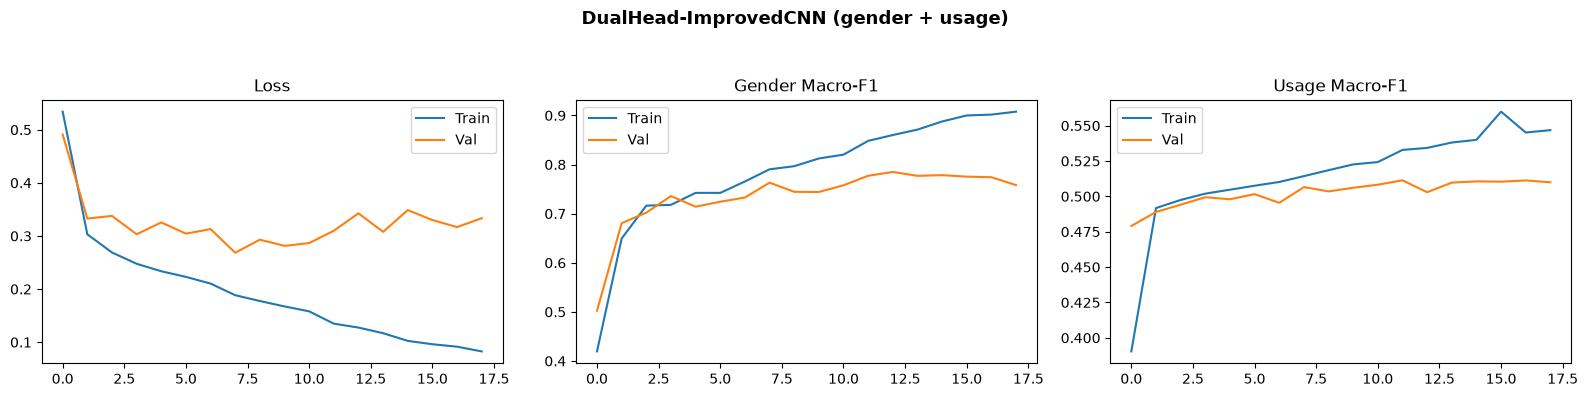

>>> Best epoch=8  train_f1_gender=0.7902  val_f1_gender=0.7631  train_f1_usage=0.5143  val_f1_usage=0.5065
Dual-head saved — gender: train_f1=0.7902 val_f1=0.7631  usage: train_f1=0.5143 val_f1=0.5065


In [36]:
ALPHA = 0.5   # weight balance between gender and usage losses

train_ds_dual = DualLabelDataset(
    train_data, meta_train, y_gender_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_dual   = DualLabelDataset(
    val_data,   meta_val,   y_gender_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_dual = DataLoader(train_ds_dual, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_dual   = DataLoader(val_ds_dual,   batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def fit_dual(model, loader_tr, loader_va, model_name='dual_model', patience=PATIENCE, lr=LR):
    """Training loop for the dual-head model. Returns gender/usage F1 for
    both train (at best epoch) and val."""
    criterion  = nn.CrossEntropyLoss()
    optimiser  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper    = EarlyStopping(patience=patience, mode='min')
    history    = {'train_loss': [], 'val_loss': [], 'train_f1_g': [], 'train_f1_u': [],
                  'val_f1_g':   [], 'val_f1_u': []}
    best_val_loss = None; best_epoch = None
    best_val_f1_g = None; best_val_f1_u = None
    # FIX: also track train F1 at the best epoch (for train-vs-val comparison)
    best_train_f1_g = None; best_train_f1_u = None

    for epoch in range(EPOCHS):
        # ── Train ──
        model.train()
        tr_loss, tr_pg, tr_pu, tr_ag, tr_au = 0.0, [], [], [], []
        for img, meta, g_lbl, u_lbl in tqdm(loader_tr, desc=f'{model_name} {epoch+1}/{EPOCHS} train', leave=True):
            img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            tr_loss += loss.item() * g_lbl.size(0)
            tr_pg.extend(g_logit.argmax(1).cpu().numpy()); tr_ag.extend(g_lbl.cpu().numpy())
            tr_pu.extend(u_logit.argmax(1).cpu().numpy()); tr_au.extend(u_lbl.cpu().numpy())
        tr_loss /= len(train_data)
        tr_f1_g = f1_score(tr_ag, tr_pg, average='macro', zero_division=0)
        tr_f1_u = f1_score(tr_au, tr_pu, average='macro', zero_division=0)

        # ── Validate ──
        model.eval()
        va_loss, va_pg, va_pu, va_ag, va_au = 0.0, [], [], [], []
        with torch.no_grad():
            for img, meta, g_lbl, u_lbl in loader_va:
                img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
                g_logit, u_logit = model(img, meta)
                loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
                va_loss += loss.item() * g_lbl.size(0)
                va_pg.extend(g_logit.argmax(1).cpu().numpy()); va_ag.extend(g_lbl.cpu().numpy())
                va_pu.extend(u_logit.argmax(1).cpu().numpy()); va_au.extend(u_lbl.cpu().numpy())
        va_loss /= len(val_data)
        va_f1_g = f1_score(va_ag, va_pg, average='macro', zero_division=0)
        va_f1_u = f1_score(va_au, va_pu, average='macro', zero_division=0)

        for k, v in zip(['train_loss','val_loss','train_f1_g','train_f1_u','val_f1_g','val_f1_u'],
                         [tr_loss, va_loss, tr_f1_g, tr_f1_u, va_f1_g, va_f1_u]):
            history[k].append(v)

        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1_g={tr_f1_g:.4f}  tr_f1_u={tr_f1_u:.4f}  '
              f'va_f1_g={va_f1_g:.4f}  va_f1_u={va_f1_u:.4f}')

        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_loss = va_loss; best_epoch = epoch + 1
            best_val_f1_g = va_f1_g; best_val_f1_u = va_f1_u
            best_train_f1_g = tr_f1_g; best_train_f1_u = tr_f1_u
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best={best_epoch})')
            break

    model = stopper.load_best_model(model)

    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1_g'], label='Train'); axes[1].plot(history['val_f1_g'], label='Val')
    axes[1].set_title('Gender Macro-F1'); axes[1].legend()
    axes[2].plot(history['train_f1_u'], label='Train'); axes[2].plot(history['val_f1_u'], label='Val')
    axes[2].set_title('Usage Macro-F1'); axes[2].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

    print(f'>>> Best epoch={best_epoch}  '
          f'train_f1_gender={best_train_f1_g:.4f}  val_f1_gender={best_val_f1_g:.4f}  '
          f'train_f1_usage={best_train_f1_u:.4f}  val_f1_usage={best_val_f1_u:.4f}')
    return model, best_val_f1_g, best_val_f1_u, best_train_f1_g, best_train_f1_u, best_epoch


torch.manual_seed(RANDOM_STATE)
dual_model, dual_f1_g, dual_f1_u, dual_train_f1_g, dual_train_f1_u, dual_epoch = fit_dual(
    DualHeadNet(META_DIM, N_GENDER, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_dual, val_loader_dual,
    model_name='DualHead-ImprovedCNN (gender + usage)'
)

torch.save(dual_model.state_dict(), OUTPUT_DIR / 'dual_head_gender_usage.pt')
print(f'Dual-head saved — gender: train_f1={dual_train_f1_g:.4f} val_f1={dual_f1_g:.4f}  '
      f'usage: train_f1={dual_train_f1_u:.4f} val_f1={dual_f1_u:.4f}')


## 12. Evaluation & comparison across all approaches

In [37]:
# ── Helper: evaluate dual-head on val set ────────────────────────────────────
def evaluate_dual(model, loader):
    model.eval(); pg, pu, ag, au = [], [], [], []
    with torch.no_grad():
        for img, meta, g_lbl, u_lbl in loader:
            img, meta = img.to(DEVICE), meta.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            pg.extend(g_logit.argmax(1).cpu().numpy()); ag.extend(g_lbl.numpy())
            pu.extend(u_logit.argmax(1).cpu().numpy()); au.extend(u_lbl.numpy())
    f1_g = f1_score(ag, pg, average='macro', zero_division=0)
    f1_u = f1_score(au, pu, average='macro', zero_division=0)
    return f1_g, f1_u, np.array(pg), np.array(pu), np.array(ag), np.array(au)


def decode_combined_predictions(model, loader, frame):
    """Run the combined-label model over `loader` and split its joint
    prediction back into (gender, usage), scored against `frame`'s true
    per-target labels. Used for both val and train sets so the gender/usage
    bar chart has a matching basis for each approach."""
    model.eval(); preds = []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
    decoded      = gender_usage_enc.inverse_transform(preds)
    pred_gender  = [gender_enc.transform([c.split('__')[0]])[0] for c in decoded]
    pred_usage   = [usage_enc.transform([c.split('__')[1]])[0]  for c in decoded]
    true_gender  = frame['gender_label'].values
    true_usage   = frame['usage_label'].values
    f1_g = f1_score(true_gender, pred_gender, average='macro', zero_division=0)
    f1_u = f1_score(true_usage,  pred_usage,  average='macro', zero_division=0)
    return f1_g, f1_u, np.array(pred_gender), np.array(pred_usage), true_gender, true_usage


# ── Run evaluations ───────────────────────────────────────────────────────────
# Approach A
f1_g_cnn    = evaluate(gender_model,        val_loader_gender)
f1_g_resnet = evaluate(gender_resnet_model, val_loader_gender)
f1_u_cnn    = evaluate(usage_model,         val_loader_usage)
f1_u_resnet = evaluate(usage_resnet_model,  val_loader_usage)

# Approach B — decode combined label back to gender/usage, VAL set
f1_g_combined, f1_u_combined, pred_gender_B, pred_usage_B, true_gender_B, true_usage_B = \
    decode_combined_predictions(combined_model, val_loader_combined, val_data)

# Approach B — same decode, TRAIN set (for the train-vs-val bar chart).
# NOTE: train_loader_combined uses a WeightedRandomSampler, so a single pass
# over it does not sample every training row uniformly. This matches the
# basis fit() already uses for the training-curve plots elsewhere in this
# notebook, but it is a different sampling basis than the LogReg train F1
# (computed on the raw, unsampled distribution) — worth a one-line caveat if
# you quote these numbers in the report.
f1_g_combined_train, f1_u_combined_train, _, _, _, _ = \
    decode_combined_predictions(combined_model, train_loader_combined, train_data)

# Approach C — single pass, keep raw predictions (previously this was re-run
# two more times in the confusion-matrix cell for no reason)
f1_g_dual, f1_u_dual, pg_dual, pu_dual, ag_dual, au_dual = evaluate_dual(dual_model, val_loader_dual)


# Gated Fusion (Section 9.7) — extra fusion strategy, evaluated the same way as Approach A
f1_g_gated = evaluate(gender_gated_model, val_loader_gender)
f1_u_gated = evaluate(usage_gated_model,  val_loader_usage)


In [38]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model': [
        'LogReg (metadata baseline)',
        f'A — MultiInput-{GENDER_ENCODER_NAME} (gender, concatenation)',
        f'A — MultiInput-{USAGE_ENCODER_NAME} (usage, concatenation)',
        'A — MultiInput-ResNet18 (gender) [pretrained, comparison only]',
        'A — MultiInput-ResNet18 (usage) [pretrained, comparison only]',
        f'A — GatedFusion-{GENDER_ENCODER_NAME} (gender)',
        f'A — GatedFusion-{USAGE_ENCODER_NAME} (usage)',
        'A — Soft-Voting Ensemble (gender)',
        'A — Soft-Voting Ensemble (usage)',
        'B — Combined (gender decoded)',
        'B — Combined (usage decoded)',
        'C — DualHead (gender head)',
        'C — DualHead (usage head)',
    ],
    'Target': [
        'gender+usage', 'gender', 'usage', 'gender', 'usage',
        'gender', 'usage', 'gender', 'usage',
        'gender', 'usage', 'gender', 'usage'
    ],
    'Train Macro-F1 (gender)': [
        logreg_gender_train_f1, gender_train_f1, None, gender_resnet_train_f1, None,
        gender_gated_train_f1, None, f1_g_softvote_train, None,
        f1_g_combined_train, None, dual_train_f1_g, None
    ],
    'Val Macro-F1 (gender)': [
        logreg_gender_f1, f1_g_cnn, None, f1_g_resnet, None,
        f1_g_gated, None, f1_g_softvote, None,
        f1_g_combined, None, f1_g_dual, None
    ],
    'Train Macro-F1 (usage)': [
        logreg_usage_train_f1, None, usage_train_f1, None, usage_resnet_train_f1,
        None, usage_gated_train_f1, None, f1_u_softvote_train,
        None, f1_u_combined_train, None, dual_train_f1_u
    ],
    'Val Macro-F1 (usage)': [
        logreg_usage_f1, None, f1_u_cnn, None, f1_u_resnet,
        None, f1_u_gated, None, f1_u_softvote,
        None, f1_u_combined, None, f1_u_dual
    ],
})

display(results_df.round(4))


,Model,Target,Train Macro-F1 (gender),Val Macro-F1 (gender),Train Macro-F1 (usage),Val Macro-F1 (usage)
0,LogReg (metadata baseline),gender+usage,0.4389,0.4416,0.4153,0.4032
1,A — MultiInput-ImprovedSmallImageEncoder (gend...,gender,0.9785,0.8222,NaN,NaN
2,"A — MultiInput-SmallImageEncoder (usage, conca...",usage,NaN,NaN,0.9777,0.5396
3,"A — MultiInput-ResNet18 (gender) [pretrained, ...",gender,0.9708,0.8232,NaN,NaN
4,"A — MultiInput-ResNet18 (usage) [pretrained, c...",usage,NaN,NaN,0.9804,0.4991
5,A — GatedFusion-ImprovedSmallImageEncoder (gen...,gender,0.9798,0.8133,NaN,NaN
6,A — GatedFusion-SmallImageEncoder (usage),usage,NaN,NaN,0.9597,0.5674
7,A — Soft-Voting Ensemble (gender),gender,0.9307,0.8158,NaN,NaN
8,A — Soft-Voting Ensemble (usage),usage,NaN,NaN,0.6655,0.5343
9,B — Combined (gender decoded),gender,0.1638,0.7928,NaN,NaN


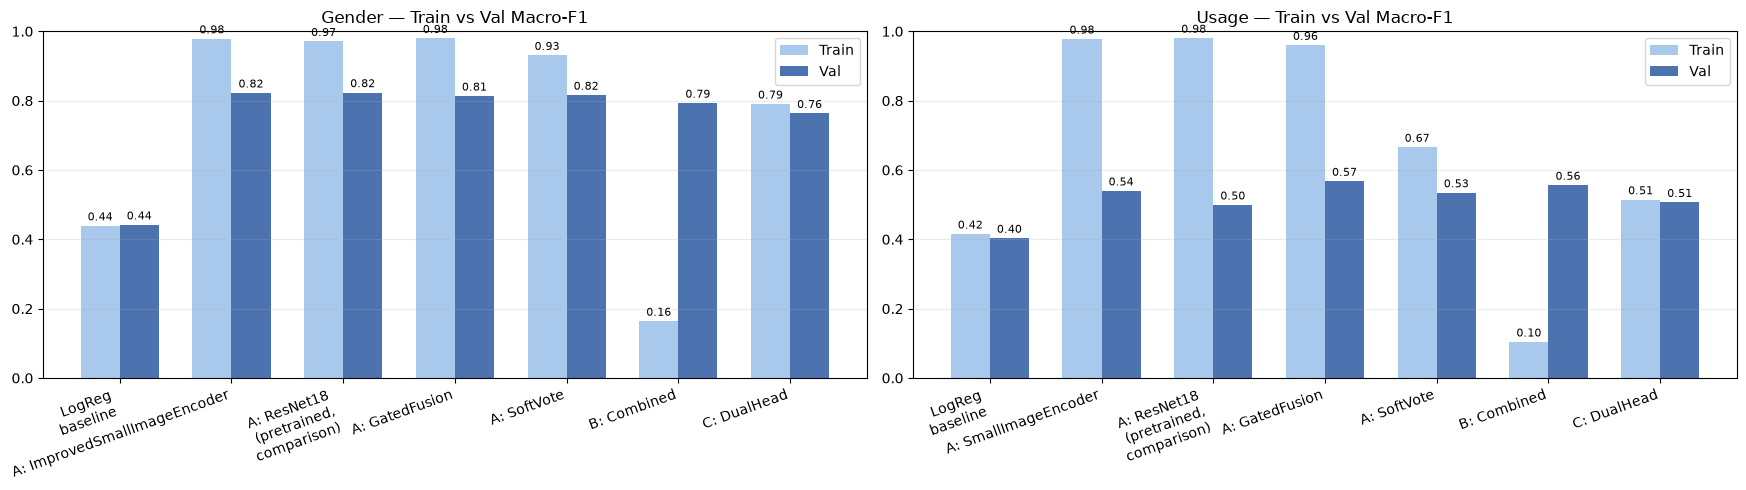

In [39]:
# ── Bar chart comparison: Train vs Validation Macro-F1 ───────────────────────
# Separate label lists per axis: gender and usage can each pick a different
# winning from-scratch encoder in 9.2, so the "MultiInput"/"GatedFusion" tick
# labels are built from GENDER_ENCODER_NAME / USAGE_ENCODER_NAME respectively.
gender_labels = ['LogReg\nbaseline', f'A: {GENDER_ENCODER_NAME}', 'A: ResNet18\n(pretrained,\ncomparison)',
                 'A: GatedFusion', 'A: SoftVote', 'B: Combined', 'C: DualHead']
usage_labels  = ['LogReg\nbaseline', f'A: {USAGE_ENCODER_NAME}', 'A: ResNet18\n(pretrained,\ncomparison)',
                 'A: GatedFusion', 'A: SoftVote', 'B: Combined', 'C: DualHead']

gender_train_scores = [logreg_gender_train_f1, gender_train_f1, gender_resnet_train_f1,
                        gender_gated_train_f1, f1_g_softvote_train, f1_g_combined_train, dual_train_f1_g]
gender_val_scores   = [logreg_gender_f1,       f1_g_cnn,        f1_g_resnet,
                        f1_g_gated,             f1_g_softvote,       f1_g_combined,       f1_g_dual]

usage_train_scores  = [logreg_usage_train_f1,  usage_train_f1,  usage_resnet_train_f1,
                        usage_gated_train_f1,   f1_u_softvote_train, f1_u_combined_train, dual_train_f1_u]
usage_val_scores    = [logreg_usage_f1,        f1_u_cnn,        f1_u_resnet,
                        f1_u_gated,             f1_u_softvote,       f1_u_combined,       f1_u_dual]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, labels, train_scores, val_scores, title in zip(
        axes,
        [gender_labels, usage_labels],
        [gender_train_scores, usage_train_scores],
        [gender_val_scores, usage_val_scores],
        ['Gender — Train vs Val Macro-F1', 'Usage — Train vs Val Macro-F1']):
    x = np.arange(len(labels))
    width = 0.35
    bars_tr = ax.bar(x - width / 2, train_scores, width, label='Train', color='#A8C8EC')
    bars_va = ax.bar(x + width / 2, val_scores,   width, label='Val',   color='#4C72B0')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylim(0, 1); ax.set_title(title)
    ax.bar_label(bars_tr, fmt='%.2f', padding=2, fontsize=8)
    ax.bar_label(bars_va, fmt='%.2f', padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()


Best gender model (from-scratch only): MultiInput-ImprovedSmallImageEncoder (val_f1=0.8222)
Best usage model  (from-scratch only): GatedFusion  (val_f1=0.5674)
[Reference — pretrained, not eligible for selection] ResNet18 gender val_f1=0.8232, usage val_f1=0.4991


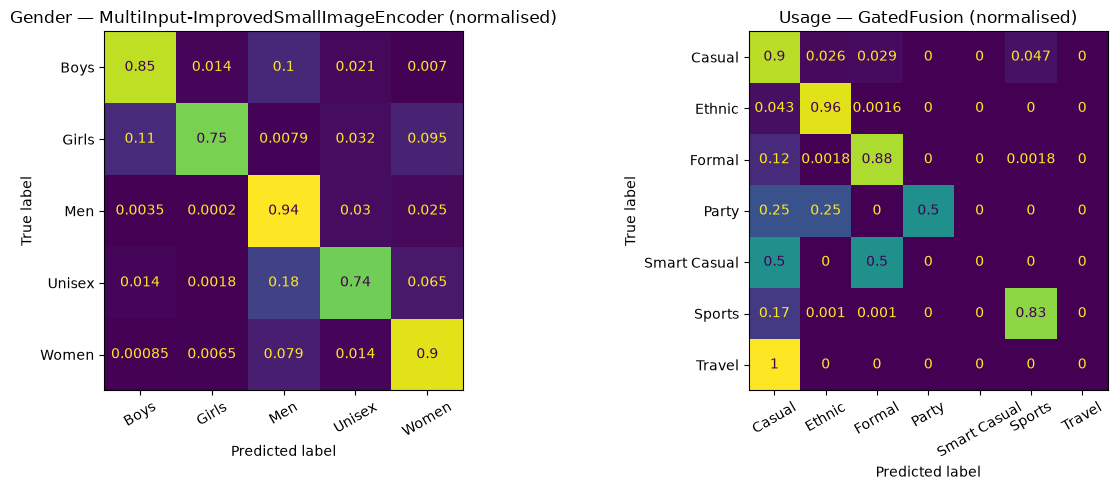


Gender classification report:
              precision    recall  f1-score   support

        Boys       0.74      0.85      0.79       143
       Girls       0.78      0.75      0.77       126
         Men       0.92      0.94      0.93      5092
      Unisex       0.66      0.74      0.70       552
       Women       0.95      0.90      0.92      3526

    accuracy                           0.91      9439
   macro avg       0.81      0.84      0.82      9439
weighted avg       0.91      0.91      0.91      9439


Usage classification report:
              precision    recall  f1-score   support

      Casual       0.96      0.90      0.93      7254
      Ethnic       0.75      0.96      0.84       611
      Formal       0.69      0.88      0.77       564
       Party       1.00      0.50      0.67         4
Smart Casual       0.00      0.00      0.00        12
      Sports       0.71      0.83      0.76       990
      Travel       0.00      0.00      0.00         4

    accuracy    

In [40]:
# ── Confusion matrices for the best FROM-SCRATCH model ────────────────────────
# NOTE: ResNet18 is ImageNet-pretrained (Section 8/9.4). The assignment spec
# requires the submitted/final model to be fully trained from scratch, and
# only allows pretrained models "for comparison" — so it is intentionally
# excluded from the candidate pool below, even if it happens to score highest.
# It still appears in the results table/bar chart above for comparison.
# Combined (B) and DualHead (C) remain in the candidate pool purely so the
# "best" selection can confirm, empirically, that separate classifiers win —
# see Section 4.2 for the full justification.
def get_preds(model, loader):
    model.eval(); p, a = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            p.extend(model(*inputs).argmax(1).cpu().numpy())
            a.extend(labels.cpu().numpy())
    return np.array(p), np.array(a)

def soft_vote_preds(cnn_model, logreg_model, loader, meta):
    cnn_probs    = get_cnn_probs(cnn_model, loader)
    logreg_probs = logreg_model.predict_proba(meta)
    return (0.5 * cnn_probs + 0.5 * logreg_probs).argmax(1)

g_pred_cnn, g_true_cnn = get_preds(gender_model, val_loader_gender)
u_pred_cnn, u_true_cnn = get_preds(usage_model,  val_loader_usage)

g_pred_gated, g_true_gated = get_preds(gender_gated_model, val_loader_gender)
u_pred_gated, u_true_gated = get_preds(usage_gated_model,  val_loader_usage)

g_pred_softvote = soft_vote_preds(gender_model, logreg_gender, val_loader_gender, meta_val)
u_pred_softvote = soft_vote_preds(usage_model,  logreg_usage,  val_loader_usage,  meta_val)

# NOTE: dict keys use GENDER_ENCODER_NAME / USAGE_ENCODER_NAME (resolved in
# 9.2.6) instead of a fixed 'SmallCNN' label, since 9.3/9.5/9.7 now plug in
# whichever from-scratch encoder actually won the 9.2 comparison per label.
gender_predictions = {
    f'MultiInput-{GENDER_ENCODER_NAME}': (g_pred_cnn, g_true_cnn),
    'GatedFusion': (g_pred_gated, g_true_gated),
    'SoftVoting':  (g_pred_softvote, y_gender_val),
    'Combined':    (pred_gender_B, true_gender_B),
    'DualHead':    (pg_dual, ag_dual),
}
usage_predictions = {
    f'MultiInput-{USAGE_ENCODER_NAME}': (u_pred_cnn, u_true_cnn),
    'GatedFusion': (u_pred_gated, u_true_gated),
    'SoftVoting':  (u_pred_softvote, y_usage_val),
    'Combined':    (pred_usage_B, true_usage_B),
    'DualHead':    (pu_dual, au_dual),
}

candidate_gender_f1 = {f'MultiInput-{GENDER_ENCODER_NAME}': f1_g_cnn, 'GatedFusion': f1_g_gated,
                        'SoftVoting': f1_g_softvote, 'Combined': f1_g_combined, 'DualHead': f1_g_dual}
candidate_usage_f1  = {f'MultiInput-{USAGE_ENCODER_NAME}': f1_u_cnn, 'GatedFusion': f1_u_gated,
                        'SoftVoting': f1_u_softvote, 'Combined': f1_u_combined, 'DualHead': f1_u_dual}

best_gender_name = max(candidate_gender_f1, key=candidate_gender_f1.get)
best_gender_f1   = candidate_gender_f1[best_gender_name]
best_usage_name  = max(candidate_usage_f1, key=candidate_usage_f1.get)
best_usage_f1    = candidate_usage_f1[best_usage_name]

print(f'Best gender model (from-scratch only): {best_gender_name} (val_f1={best_gender_f1:.4f})')
print(f'Best usage model  (from-scratch only): {best_usage_name}  (val_f1={best_usage_f1:.4f})')
print(f'[Reference — pretrained, not eligible for selection] '
      f'ResNet18 gender val_f1={f1_g_resnet:.4f}, usage val_f1={f1_u_resnet:.4f}')

g_pred, g_true = gender_predictions[best_gender_name]
u_pred, u_true = usage_predictions[best_usage_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    g_true, g_pred, display_labels=gender_enc.classes_,
    ax=axes[0], xticks_rotation=30, colorbar=False, normalize='true')
axes[0].set_title(f'Gender — {best_gender_name} (normalised)')

ConfusionMatrixDisplay.from_predictions(
    u_true, u_pred, display_labels=usage_enc.classes_,
    ax=axes[1], xticks_rotation=30, colorbar=False, normalize='true')
axes[1].set_title(f'Usage — {best_usage_name} (normalised)')

plt.tight_layout()
plt.show()

print('\nGender classification report:')
print(classification_report(g_true, g_pred, target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report:')
print(classification_report(u_true, u_pred, target_names=usage_enc.classes_,  zero_division=0))


## 13. Test-set prediction (submission)

In [41]:
# Load the test prediction template
pred_df = pd.read_csv(TEST_PRED_CSV)
pred_df['id'] = pred_df['id'].astype(str).str.strip()
print(pred_df.shape)
pred_df.head(3)

(5829, 5)


,id,gender,articleType,season,usage
0,52003,NaN,NaN,NaN,NaN
1,52007,NaN,NaN,NaN,NaN
2,52017,NaN,NaN,NaN,NaN


In [42]:
# ── Use the best (from-scratch-eligible) gender and usage models for submission ──
# best_gender_name / best_usage_name come from Section 12, and by construction
# can only be f'MultiInput-{GENDER/USAGE_ENCODER_NAME}', 'GatedFusion', 'SoftVoting',
# 'Combined', or 'DualHead' — ResNet18 (pretrained) is excluded from selection,
# per the assignment's "fully train your own" rule.

class TestDataset(Dataset):
    """Test-set dataset — image only (no labels). Returns (image, id)."""
    def __init__(self, ids, image_dir, transform):
        self.ids       = ids
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        img_id = self.ids[i]
        path   = self.image_dir / f"{img_id}.jpg"
        with Image.open(path) as im:
            img = self.transform(im.convert('RGB'))
        return img, img_id


test_ids = pred_df['id'].tolist()
test_ds  = TestDataset(test_ids, IMAGES_TEST_DIR, eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def build_test_metadata():
    """OHE-encode test metadata, or zero-fill with a loud warning if the
    prediction template doesn't carry the metadata columns."""
    if all(c in pred_df.columns for c in META_COLS):
        return ohe.transform(pred_df[META_COLS])
    print("WARNING: metadata columns not available in test CSV — using zero "
          "metadata. This will likely hurt performance for MultiInput models; "
          "verify styles_prediction.csv actually lacks these columns before "
          "trusting this submission.")
    return np.zeros((len(pred_df), META_DIM))

test_meta = build_test_metadata()


def predict_single_target(model, encoder):
    """Inference for a MultiInputNet / GatedFusionNet (image+metadata -> one head) model."""
    model.eval(); results = {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits = model(imgs.to(DEVICE), meta)
            preds  = logits.argmax(1).cpu().numpy()
            for img_id, p in zip(ids, preds):
                results[img_id] = encoder.inverse_transform([p])[0]
            idx += bs
    return results


def predict_softvote(cnn_model, logreg_model, encoder):
    """Soft-vote inference: unweighted 50/50 average of CNN softmax and
    LogReg predict_proba, then argmax."""
    cnn_model.eval(); results = {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (soft-vote)'):
            bs         = imgs.size(0)
            meta_batch = test_meta[idx:idx+bs]
            meta_t     = torch.tensor(meta_batch, dtype=torch.float32).to(DEVICE)
            cnn_probs    = torch.softmax(cnn_model(imgs.to(DEVICE), meta_t), dim=1).cpu().numpy()
            logreg_probs = logreg_model.predict_proba(meta_batch)
            preds        = (0.5 * cnn_probs + 0.5 * logreg_probs).argmax(1)
            for img_id, p in zip(ids, preds):
                results[img_id] = encoder.inverse_transform([p])[0]
            idx += bs
    return results


def predict_dual_head(model):
    """Inference for DualHeadNet — returns (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (dual head)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            g_logit, u_logit = model(imgs.to(DEVICE), meta)
            g_preds = g_logit.argmax(1).cpu().numpy()
            u_preds = u_logit.argmax(1).cpu().numpy()
            for img_id, g, u in zip(ids, g_preds, u_preds):
                g_results[img_id] = gender_enc.inverse_transform([g])[0]
                u_results[img_id] = usage_enc.inverse_transform([u])[0]
            idx += bs
    return g_results, u_results


def predict_combined(model):
    """Inference for the combined-label model — splits the joint class
    back into (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (combined)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits  = model(imgs.to(DEVICE), meta)
            preds   = logits.argmax(1).cpu().numpy()
            decoded = gender_usage_enc.inverse_transform(preds)
            for img_id, c in zip(ids, decoded):
                g, u = c.split('__')
                g_results[img_id] = g
                u_results[img_id] = u
            idx += bs
    return g_results, u_results


# ── Only run inference for approaches that actually won, avoiding wasted passes ──
if best_gender_name == 'DualHead' or best_usage_name == 'DualHead':
    g_from_dual, u_from_dual = predict_dual_head(dual_model)
if best_gender_name == 'Combined' or best_usage_name == 'Combined':
    g_from_combined, u_from_combined = predict_combined(combined_model)

gender_source = {
    f'MultiInput-{GENDER_ENCODER_NAME}': lambda: predict_single_target(gender_model, gender_enc),
    'GatedFusion': lambda: predict_single_target(gender_gated_model, gender_enc),
    'SoftVoting':  lambda: predict_softvote(gender_model, logreg_gender, gender_enc),
    'Combined':    lambda: g_from_combined,
    'DualHead':    lambda: g_from_dual,
}
usage_source = {
    f'MultiInput-{USAGE_ENCODER_NAME}': lambda: predict_single_target(usage_model, usage_enc),
    'GatedFusion': lambda: predict_single_target(usage_gated_model, usage_enc),
    'SoftVoting':  lambda: predict_softvote(usage_model, logreg_usage, usage_enc),
    'Combined':    lambda: u_from_combined,
    'DualHead':    lambda: u_from_dual,
}

gender_preds = gender_source[best_gender_name]()
usage_preds  = usage_source[best_usage_name]()

pred_df['gender'] = pred_df['id'].map(gender_preds)
pred_df['usage']  = pred_df['id'].map(usage_preds)

pred_df.to_csv(OUTPUT_DIR / 'task3_predictions.csv', index=False)
print(f"Predictions saved — {len(pred_df)} rows, "
      f"using gender={best_gender_name}, usage={best_usage_name} (from-scratch models only)")
pred_df.head()


Predicting test set:   0%|          | 0/92 [00:00<?, ?it/s]

Predicting test set:   0%|          | 0/92 [00:00<?, ?it/s]

Predictions saved — 5829 rows, using gender=MultiInput-ImprovedSmallImageEncoder, usage=GatedFusion (from-scratch models only)


,id,gender,articleType,season,usage
0,52003,Men,NaN,NaN,Casual
1,52007,Women,NaN,NaN,Casual
2,52017,Men,NaN,NaN,Casual
3,52021,Women,NaN,NaN,Casual
4,52023,Men,NaN,NaN,Casual


## 14. Save models & encoders

In [43]:
models_to_save = {
    'gender_multiinput_smallcnn.pt':    gender_model,
    'gender_multiinput_resnet18.pt':    gender_resnet_model,
    'gender_gatedfusion.pt':            gender_gated_model,
    'usage_multiinput_smallcnn.pt':     usage_model,
    'usage_multiinput_resnet18.pt':     usage_resnet_model,
    'usage_gatedfusion.pt':             usage_gated_model,
    'combined_gender_usage_smallcnn.pt': combined_model,
    'dual_head_gender_usage.pt':         dual_model,
}

for fname, model in models_to_save.items():
    torch.save(model.state_dict(), OUTPUT_DIR / fname)
    print(f'Saved {fname}')

print(f'\nAll files in {OUTPUT_DIR}:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<45} {size_mb:.1f} MB')


Saved gender_multiinput_smallcnn.pt
Saved gender_multiinput_resnet18.pt
Saved gender_gatedfusion.pt
Saved usage_multiinput_smallcnn.pt
Saved usage_multiinput_resnet18.pt
Saved usage_gatedfusion.pt
Saved combined_gender_usage_smallcnn.pt
Saved dual_head_gender_usage.pt

All files in ../outputs/task3_models:
  baselines                                     0.0 MB
  combined_gender_usage_smallcnn.pt             5.5 MB
  dual_head_gender_usage.pt                     5.4 MB
  gender_encoder.joblib                         0.0 MB
  gender_gatedfusion.pt                         5.5 MB
  gender_imageonly_smallcnn.pt                  5.2 MB
  gender_multiinput_resnet18.pt                 45.4 MB
  gender_multiinput_smallcnn.pt                 5.4 MB
  gender_usage_encoder.joblib                   0.0 MB
  image_only                                    0.0 MB
  ohe_metadata.joblib                           0.0 MB
  task3_artifacts.json                          0.0 MB
  task3_predictions.csv        

### 14.1 Artefacts for the chained pipeline notebook


In [ ]:

manifest = {
    'image_size_hw': [int(IMG_HEIGHT), int(IMG_WIDTH)],
    'normalization_mean': list(NORM_MEAN),
    'normalization_std': list(NORM_STD),
    'metadata_features': list(META_COLS),
    'metadata_dim': int(META_DIM),
    'targets': {},
}

for tag, target_col, imgonly, imgonly_name, multi, enc, n_cls in [
    ('gender', 'gender', best_gender_imgonly['model'], best_gender_imgonly_name,
     gender_model, gender_enc, N_GENDER),
    ('usage', 'usage', best_usage_imgonly['model'], best_usage_imgonly_name,
     usage_model, usage_enc, N_USAGE),
]:
    torch.save({
        'model_state_dict': imgonly.state_dict(),
        'wrapper': 'ImageOnlyNet',
        'image_encoder': type(imgonly.image).__name__,
        'out_dim': int(imgonly.image.out_dim),
        'n_classes': int(n_cls),
        'classes': enc.classes_.tolist(),
        'selected_as': imgonly_name,
        'pretrained': False,
    }, OUTPUT_DIR / f'{tag}_imageonly_smallcnn.pt')

    torch.save({
        'model_state_dict': multi.state_dict(),
        'wrapper': 'MultiInputNet',
        'image_encoder': type(multi.image).__name__,
        'out_dim': int(multi.image.out_dim),
        'metadata_dim': int(META_DIM),
        'metadata_features': list(META_COLS),
        'n_classes': int(n_cls),
        'classes': enc.classes_.tolist(),
        'target_column': target_col,
        'pretrained': False,
    }, OUTPUT_DIR / f'{tag}_multiinput_smallcnn.pt')

    manifest['targets'][tag] = {
        'target_column': target_col,
        'classes': enc.classes_.tolist(),
        'image_only_encoder': type(imgonly.image).__name__,
        'image_only_selected_as': imgonly_name,
        'multi_input_encoder': type(multi.image).__name__,
        'files': {
            'label_encoder': f'{tag}_encoder.joblib',
            'metadata_one_hot': 'ohe_metadata.joblib',
            'image_only': f'{tag}_imageonly_smallcnn.pt',
            'multi_input': f'{tag}_multiinput_smallcnn.pt',
        },
    }

(OUTPUT_DIR / 'task3_artifacts.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print('Artefacts for the pipeline notebook:')
for name in ['gender_imageonly_smallcnn.pt', 'usage_imageonly_smallcnn.pt',
             'gender_multiinput_smallcnn.pt', 'usage_multiinput_smallcnn.pt',
             'gender_encoder.joblib', 'usage_encoder.joblib', 'ohe_metadata.joblib',
             'task3_artifacts.json']:
    p = OUTPUT_DIR / name
    size = f"{p.stat().st_size / 1024:8.1f} KB" if p.exists() else ""
    print(f"  [{'OK' if p.exists() else 'MISSING':>7}] {name:34s} {size}")

print(f"\nNote: the *_imageonly_smallcnn.pt names are kept for compatibility with the pipeline "
      f"notebook; the encoder actually inside them is whichever from-scratch encoder won in "
      f"Section 9.2.4 -- gender: {manifest['targets']['gender']['image_only_encoder']}, "
      f"usage: {manifest['targets']['usage']['image_only_encoder']}. The pipeline reads the "
      f"class name from the checkpoint rather than assuming one.")

Artefacts for the pipeline notebook:
  [     OK] gender_imageonly_smallcnn.pt         5060.7 KB
  [     OK] usage_imageonly_smallcnn.pt          1805.9 KB
  [     OK] gender_multiinput_smallcnn.pt        5309.2 KB
  [     OK] usage_multiinput_smallcnn.pt         2054.4 KB
  [     OK] gender_encoder.joblib                   0.5 KB
  [     OK] usage_encoder.joblib                    0.5 KB
  [     OK] ohe_metadata.joblib                     4.4 KB
  [     OK] task3_artifacts.json                    1.6 KB

Note: the *_imageonly_smallcnn.pt names are kept for compatibility with the pipeline notebook; the encoder actually inside them is whichever from-scratch encoder won in Section 9.2.4 -- gender: ImprovedSmallImageEncoder, usage: SmallImageEncoder. The pipeline reads the class name from the checkpoint rather than assuming one.
